In [2]:
import yt 
import numpy as np

def _gamma(field, data):
    u1 = data[('gas', 'four_velocity_r')]
    u2 = data[('gas', 'four_velocity_theta')]
    u3 = data[('gas', 'four_velocity_z')]
    c = data.ds.quan(1.0, 'code_velocity')
    return (1 + (u1/c)**2 + (u2/c)**2 + (u3/c)**2)**0.5


yt.add_field(('gas', 'lorentz_gamma'), function=_gamma, units="", sampling_type = "cell", dimensions = yt.units.dimensionless)
# Cartesian velocity components derived directly from the native cylindrical fields.
# ('athena_pp', 'vel1') = v_R,  ('athena_pp', 'vel2') = v_phi
# ('index', 'theta')    = azimuthal angle phi of each cell
# v_x = v_R*cos(phi) - v_phi*sin(phi)
# v_y = v_R*sin(phi) + v_phi*cos(phi)
def _vel_cyl_x(field, data):
    phi  = data[('index', 'theta')]
    vr   = data[('athena_pp', 'vel1')]
    vphi = data[('athena_pp', 'vel2')]
    return vr * np.cos(phi) - vphi * np.sin(phi)

def _vel_cyl_y(field, data):
    phi  = data[('index', 'theta')]
    vr   = data[('athena_pp', 'vel1')]
    vphi = data[('athena_pp', 'vel2')]
    return vr * np.sin(phi) + vphi * np.cos(phi)

yt.add_field(('gas', 'vel_cyl_x'), function=_vel_cyl_x,
             units='code_velocity', sampling_type='cell', force_override=True)
yt.add_field(('gas', 'vel_cyl_y'), function=_vel_cyl_y,
             units='code_velocity', sampling_type='cell', force_override=True)

In [3]:
def _enthalpy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return 1 + 4*P/(rho*c**2)


yt.add_field(('gas', 'enthalpy'), function=_enthalpy, units="", sampling_type="cell", dimensions=yt.units.dimensionless)

def _entropy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return P/rho**(4/3)

yt.add_field(('gas', 'entropy'), function=_entropy, units="code_length**3/(code_mass**(1/3)*code_time**2)", sampling_type="cell")

# Entropy Tracking

yt : [WARNING  ] 2026-05-19 12:46:25,106 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-19 12:46:25,107 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-19 12:46:25,108 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-19 12:46:25,108 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-19 12:46:25,147 Parameters: current_time              = 0.6300002622196839
yt : [INFO     ] 2026-05-19 12:46:25,147 Parameters: domain_dimensions         = [1200  800    1]
yt : [INFO     ] 2026-05-19 12:46:25,147 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-05-19 12:46:25,148 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-05-19 12:46:25,148 Parameters: cosmological_simulation   = 0


Shock fronts at theta=4.712 rad: 1.002 R_*
Shock fronts at theta=4.695 rad: 1.002 R_*
Shock fronts at theta=4.677 rad: 1.002 R_*
Shock fronts at theta=4.660 rad: 1.002 R_*
Shock fronts at theta=4.642 rad: 1.002 R_*
Shock fronts at theta=4.625 rad: 1.002 R_*
Shock fronts at theta=4.607 rad: 1.002 R_*
Shock fronts at theta=4.590 rad: 1.002 R_*
Shock fronts at theta=4.572 rad: 1.002 R_*
Shock fronts at theta=4.554 rad: 1.002 R_*
Shock fronts at theta=4.537 rad: 1.002 R_*
Shock fronts at theta=4.519 rad: 1.002 R_*
Shock fronts at theta=4.502 rad: 1.002 R_*
Shock fronts at theta=4.484 rad: 1.002 R_*
Shock fronts at theta=4.467 rad: 1.002 R_*
Shock fronts at theta=4.449 rad: 1.002 R_*
Shock fronts at theta=4.432 rad: 1.002 R_*
Shock fronts at theta=4.414 rad: 1.002 R_*
Shock fronts at theta=4.396 rad: 1.002 R_*
Shock fronts at theta=4.379 rad: 1.002 R_*
Shock fronts at theta=4.361 rad: 1.002 R_*
Shock fronts at theta=4.344 rad: 1.002 R_*
Shock fronts at theta=4.326 rad: 1.002 R_*
Shock front

/tmp/ipykernel_3734954/66237490.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


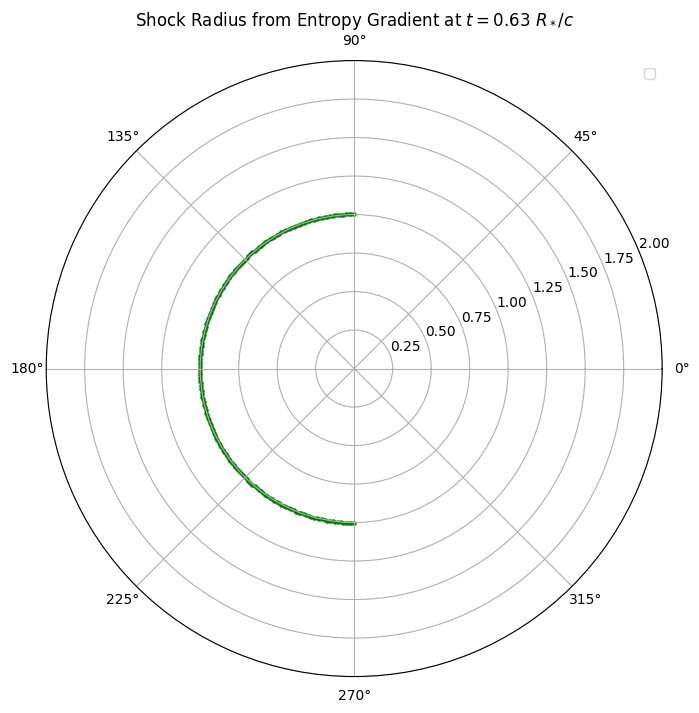

yt : [INFO     ] 2026-05-19 12:46:28,978 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-19 12:46:28,978 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-19 12:46:28,978 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-05-19 12:46:28,980 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-19 12:46:28,981 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-19 12:46:28,984 Making a fixed resolution buffer of (('gas', 'entropy')) 800 by 800



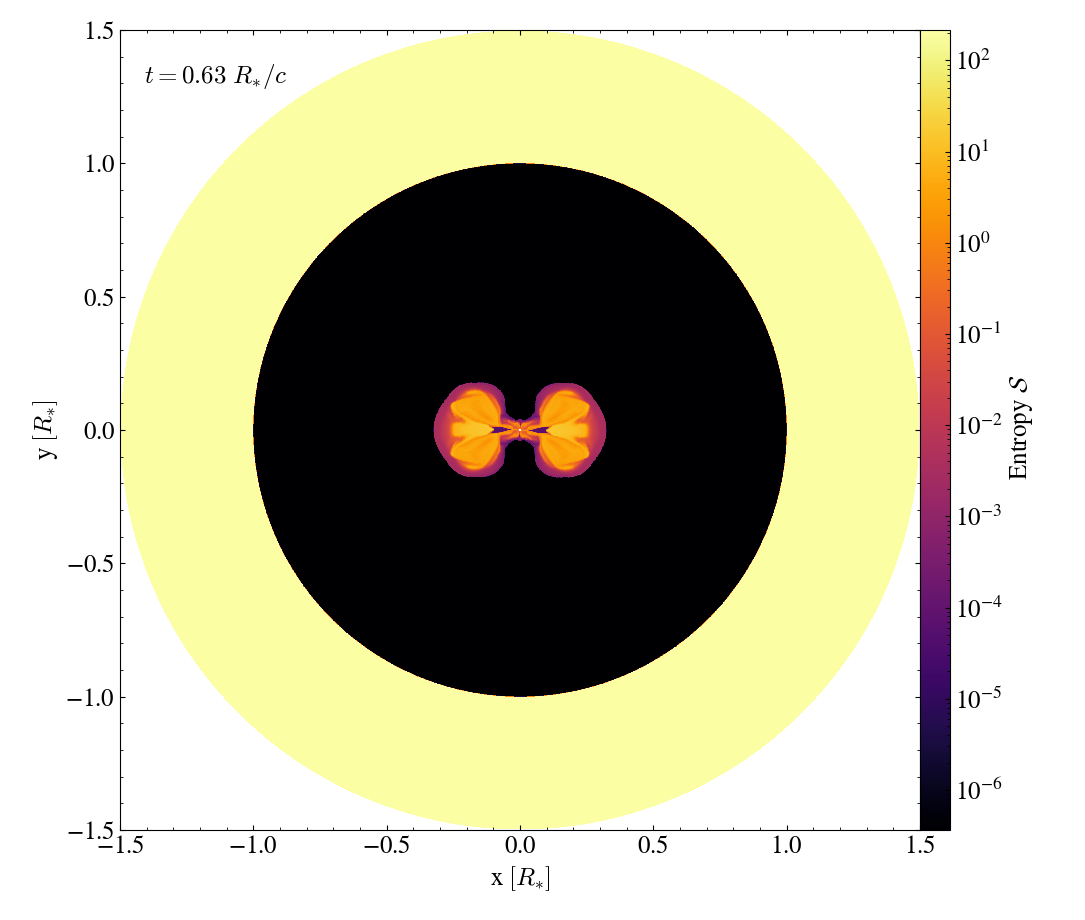

In [4]:
import yt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1D velocity profile at a fixed azimuthal angle
theta_vals = np.linspace(3*np.pi/2, np.pi/2, 180)  # example theta values
z_val     = 0.5   #doesnt matter

ds_entr = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.00630.athdf')


r_shock_entropy = []  # list of lists: 1 or more radii per theta

for theta_val in theta_vals:
    ray = ds_entr.ortho_ray(0, (theta_val, z_val))

    df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
    df_entr = df_entr.sort_values('r').reset_index(drop=True)

    if len(df_entr) < 2:
        r_shock_entropy.append([np.nan])
        continue

    # Shock has hit the surface: outer boundary entropy is still unshocked
    if np.log10(df_entr['entropy'].iloc[-1]) < 1:
        r_shock_entropy.append([1.5])
        print(f"Shock at boundary for theta={theta_val:.3f} rad")
        continue

    dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
    abs_grad = np.abs(dlogS_dr)

    peaks, _ = find_peaks(abs_grad, height=100, distance=10)
    peak_radii = sorted(
        [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2],
        reverse=True
    )

    max_distance = 0.3  # tune: max allowed distance from outermost shock front

    selected = []
    if peak_radii:
        r_outer = peak_radii[0]
        selected = [r for r in peak_radii if r_outer - r <= max_distance]

    # Separately keep stellar surface peak near R=1.0
    surface_peaks = [r for r in peak_radii if 0.85 < r < 1.15]
    if surface_peaks and (not selected or min(abs(s - 1.0) for s in selected) > 0.1):
        selected.append(min(surface_peaks, key=lambda r: abs(r - 1.0)))

    radii = sorted(selected)
    if radii:
        print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
        r_shock_entropy.append(radii)
    else:
        r_shock_entropy.append([np.nan])
    # fig, ax = plt.subplots()
    # ax.plot(df_entr['r'], df_entr['entropy'], label='Entropy')
    # ax.plot(df_entr['r'], abs_grad, label='|dlogS/dr|', alpha=0.5)
    # for r in radii:
    #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
    # ax.set_xlabel(r"$r \ [R_*]$")
    # ax.set_ylabel(r"Entropy $\mathcal{S}$")
    # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds_entr.current_time):.2f}\ R_*/c$") 
    # ax.legend()
    # plt.show()

# Flatten for polar plot: duplicate theta for entries with two fronts
plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
plot_r     = [r  for rs in r_shock_entropy for r in rs]

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(12, 8))
ax.scatter(plot_theta, plot_r, marker='o', color='g', s=5)
ax.set_rlim(0, 2)
ax.set_title(rf"Shock Radius from Entropy Gradient at $t = {float(ds_entr.current_time):.2f}\ R_*/c$")
ax.legend()
plt.show()

p = yt.SlicePlot(ds_entr, 'z', ('gas', 'entropy'))
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(("gas", "entropy"), "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(("gas", "entropy"), r" Entropy $\mathcal{S}$")

# Lorentz Factor tracking

yt : [WARNING  ] 2026-05-19 12:46:30,120 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-19 12:46:30,120 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-19 12:46:30,121 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-19 12:46:30,121 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-19 12:46:30,147 Parameters: current_time              = 0.9000013308920282
yt : [INFO     ] 2026-05-19 12:46:30,147 Parameters: domain_dimensions         = [1200  800    1]
yt : [INFO     ] 2026-05-19 12:46:30,148 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-05-19 12:46:30,148 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-05-19 12:46:30,148 Parameters: cosmological_simulation   = 0


Shock fronts at theta=0.000 rad: 0.255, 0.276 R_*
Shock fronts at theta=0.035 rad: 0.245 R_*
Shock fronts at theta=0.070 rad: 0.234 R_*
Shock fronts at theta=0.105 rad: 0.221 R_*
Shock fronts at theta=0.140 rad: 0.215, 0.313 R_*
Shock fronts at theta=0.176 rad: 0.210, 0.318 R_*
Shock fronts at theta=0.211 rad: 0.208, 0.319 R_*
Shock fronts at theta=0.246 rad: 0.208, 0.320 R_*
Shock fronts at theta=0.281 rad: 0.206, 0.314 R_*
Shock fronts at theta=0.316 rad: 0.204 R_*
Shock fronts at theta=0.386 rad: 0.373 R_*
Shock fronts at theta=0.421 rad: 0.296 R_*
Shock fronts at theta=0.456 rad: 0.270 R_*
Shock fronts at theta=0.491 rad: 0.261 R_*
Shock fronts at theta=0.527 rad: 0.248 R_*
Shock fronts at theta=2.633 rad: 0.259 R_*
Shock fronts at theta=2.668 rad: 0.268 R_*
Shock fronts at theta=2.703 rad: 0.288 R_*
Shock fronts at theta=2.738 rad: 0.373 R_*
Shock fronts at theta=2.843 rad: 0.205, 0.308 R_*
Shock fronts at theta=2.878 rad: 0.206, 0.320 R_*
Shock fronts at theta=2.913 rad: 0.206, 0

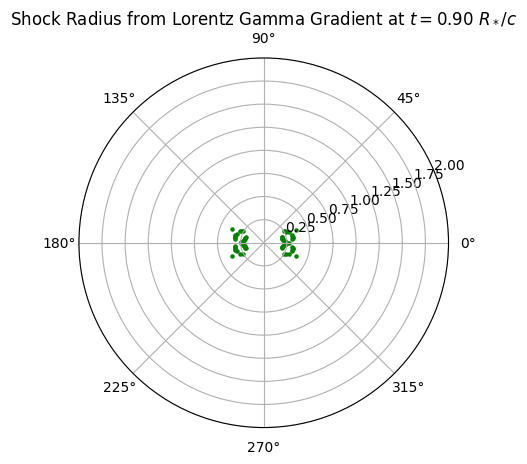

yt : [INFO     ] 2026-05-19 12:46:33,451 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-19 12:46:33,451 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-19 12:46:33,452 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-05-19 12:46:33,453 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-19 12:46:33,454 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-19 12:46:33,454 Making a fixed resolution buffer of (('gas', 'lorentz_gamma')) 800 by 800



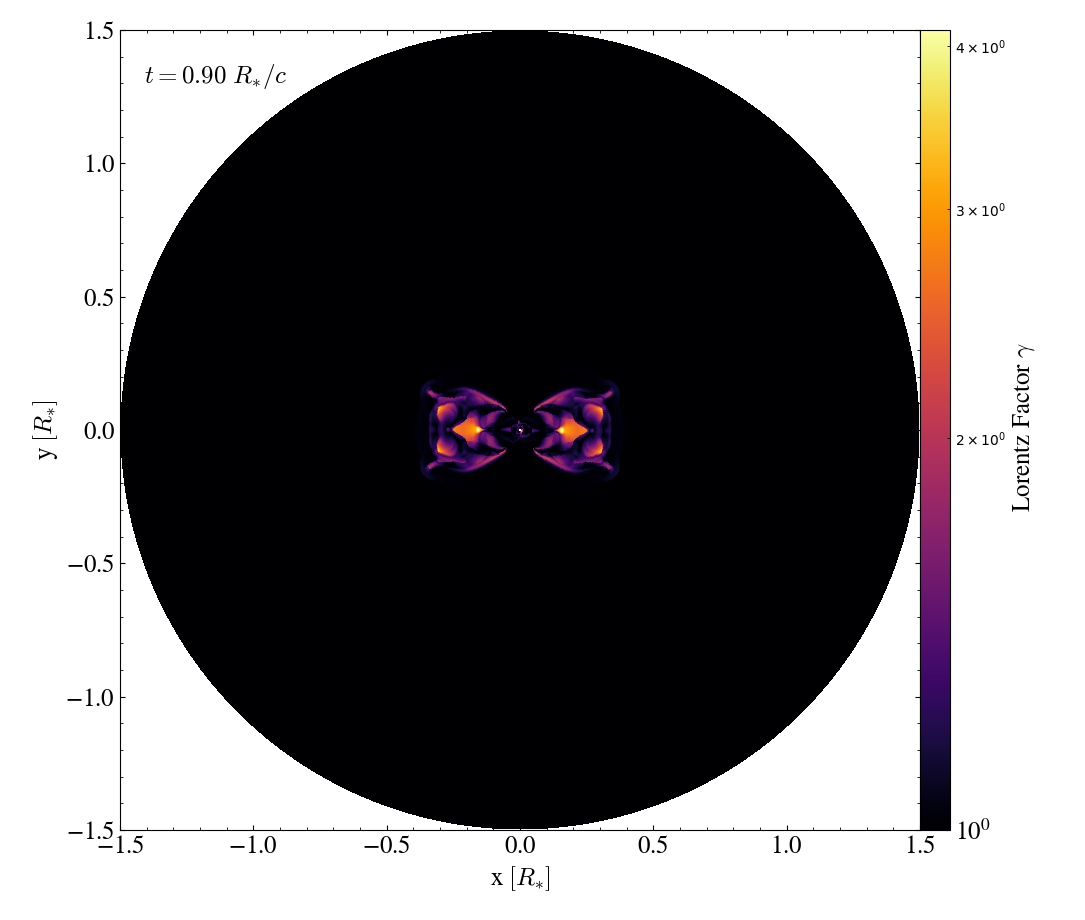

In [5]:
ds_gamma = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.00900.athdf')

theta_vals = np.linspace(0, 2*np.pi, 180)  # example theta values

radii_gamma = []  # one entry per theta_val: list of radii or [nan]


for theta_val in theta_vals:
    ray = ds_gamma.ortho_ray(0, (theta_val, z_val))
    df_gamma = ray.to_dataframe([('index', 'r'), ('gas', 'lorentz_gamma')])
    df_gamma = df_gamma.sort_values('r').reset_index(drop=True)

    if len(df_gamma) < 2:
        radii_gamma.append([np.nan])  # was: bare continue (bug 1)
        continue

    dgamma_dr = np.gradient(df_gamma['lorentz_gamma'], df_gamma['r'])
    abs_grad = np.abs(dgamma_dr)

    peaks, _ = find_peaks(abs_grad, height=100, distance=10)
    radii = [float(df_gamma['r'].iloc[i]) for i in peaks if df_gamma['r'].iloc[i] > 0.2]

    if radii:
        print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
        radii_gamma.append(radii)
    else:
        radii_gamma.append([np.nan])  # was: nothing (bug 2)

    # fig, ax = plt.subplots()
    # ax.plot(df_gamma['r'], df_gamma['lorentz_gamma'], label='Lorentz Gamma')
    # ax.plot(df_gamma['r'], dgamma_dr, label='dGamma/dr', alpha=0.5)
    # for r in radii:
    #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
    # ax.set_xlabel(r"$r \ [R_*]$")
    # ax.set_ylabel(r"Lorentz Factor $\gamma$")
    # ax.set_title(rf"Lorentz Factor at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds_gamma.current_time):.2f}\ R_*/c$")
    # ax.legend()
    # plt.show()

# Flatten using zip so theta tracks actual detection angles (bug 3 fix)
plot_theta = [th for th, rs in zip(theta_vals, radii_gamma) for _ in rs]
plot_r     = [r  for rs in radii_gamma for r in rs]

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.scatter(plot_theta, plot_r, marker='o', color='g', s=5)
ax.set_rlim(0, 2)
ax.set_title(rf"Shock Radius from Lorentz Gamma Gradient at $t = {float(ds_gamma.current_time):.2f}\ R_*/c$")
plt.show()

p = yt.SlicePlot(ds_gamma, 'z', ('gas', 'lorentz_gamma'))
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(("gas", "lorentz_gamma"), "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(("gas", "lorentz_gamma"), r" Lorentz Factor $\gamma$")


# The in-sim tracking

Requested t=2.6000, using t=2.6000  (364 fronts)


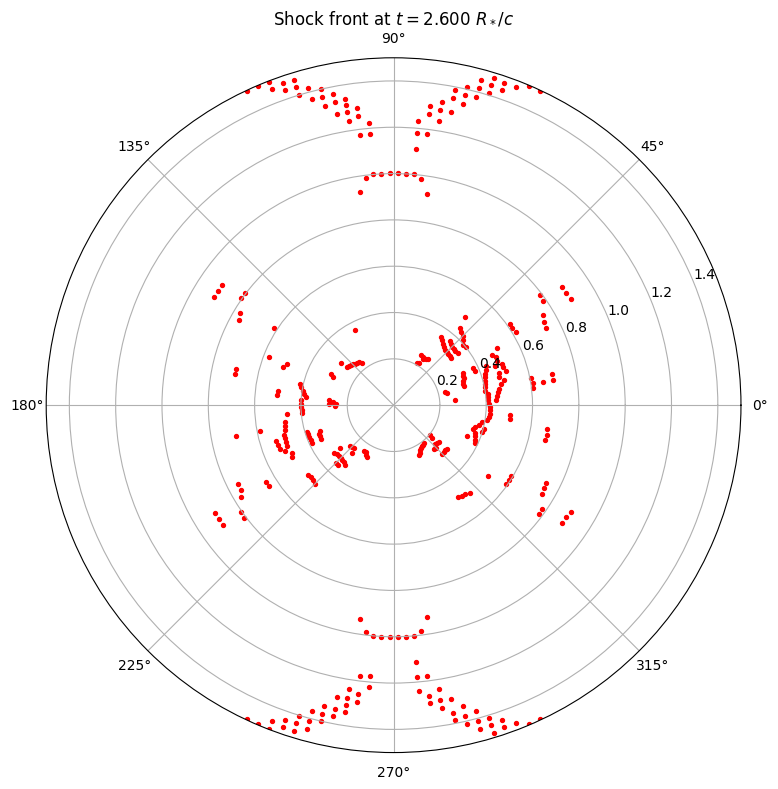

,angle_deg,r_shock,vr,v_tang
time,,,,
2.59997,1,0.412347,0.372442,0.124046
2.59997,3,0.444552,0.438451,0.043031
2.59997,3,0.406491,0.348411,0.120795
2.59997,5,0.447479,0.438111,0.103318
2.59997,5,0.409419,0.431814,0.106416
...,...,...,...,...
2.59997,353,0.415274,0.399030,-0.114643
2.59997,355,0.506034,0.320830,-0.001820
2.59997,355,0.418202,0.442331,-0.101621


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fronts = pd.read_csv('/scratch/aripoll/athena_out/outputs/shock_front.csv', index_col=0)

def get_fronts_at(t):
    """Return shock front rows at the timestep closest to t."""
    times = fronts.index.unique()
    closest_t = times[np.argmin(np.abs(times - t))]
    df = fronts.loc[[closest_t]]
    print(f"Requested t={t:.4f}, using t={closest_t:.4f}  ({len(df)} fronts)")
    return df

def plot_fronts_at(t):
    df = get_fronts_at(t)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    ax.scatter(np.deg2rad(df['angle_deg']), df['r_shock'], marker='o', s=8, c='red')
    ax.set_rlim(0, 1.5)
    ax.set_title(rf"Shock front at $t = {df.index[0]:.3f}\ R_*/c$")
    plt.tight_layout()
    plt.show()
    return df

# --- usage: change t_query to inspect any time ---
t_query = 2.6
df = plot_fronts_at(t_query)
df

Requested t=1.8000, using t=1.8004  (301 fronts)


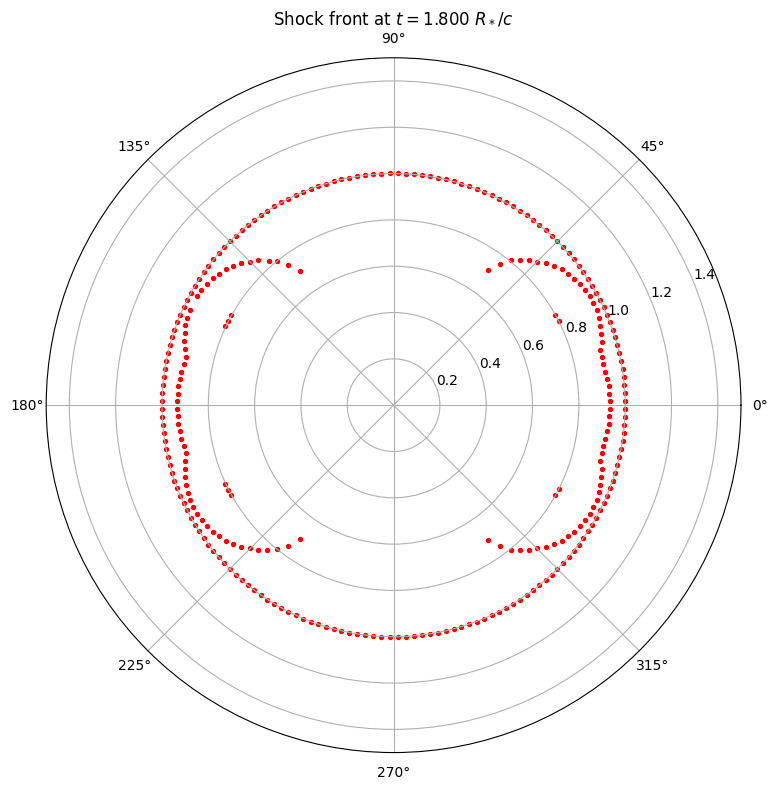

Requested t=1.8179, using t=1.8184  (271 fronts)


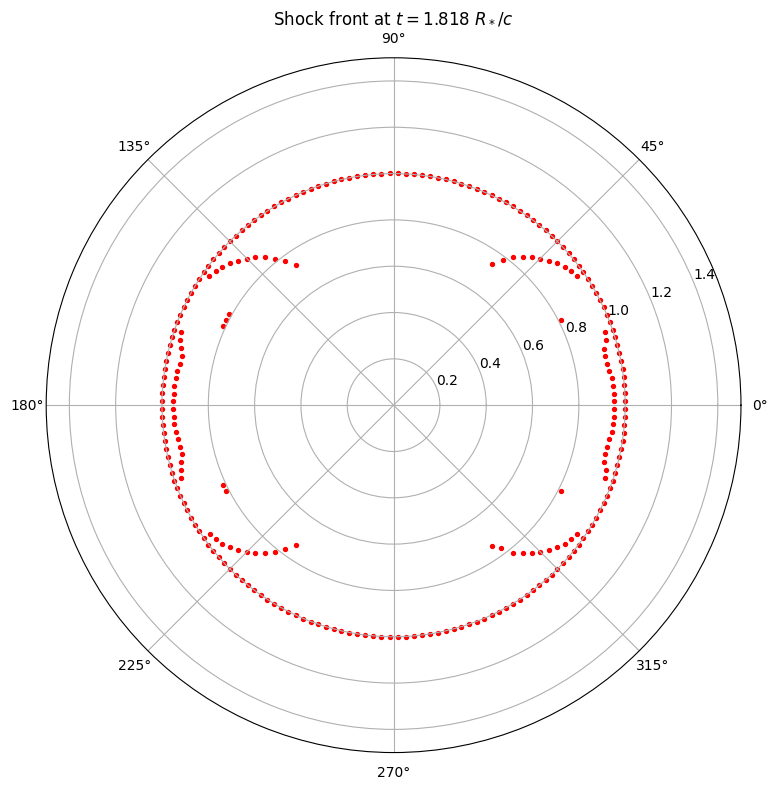

Requested t=1.8359, using t=1.8364  (251 fronts)


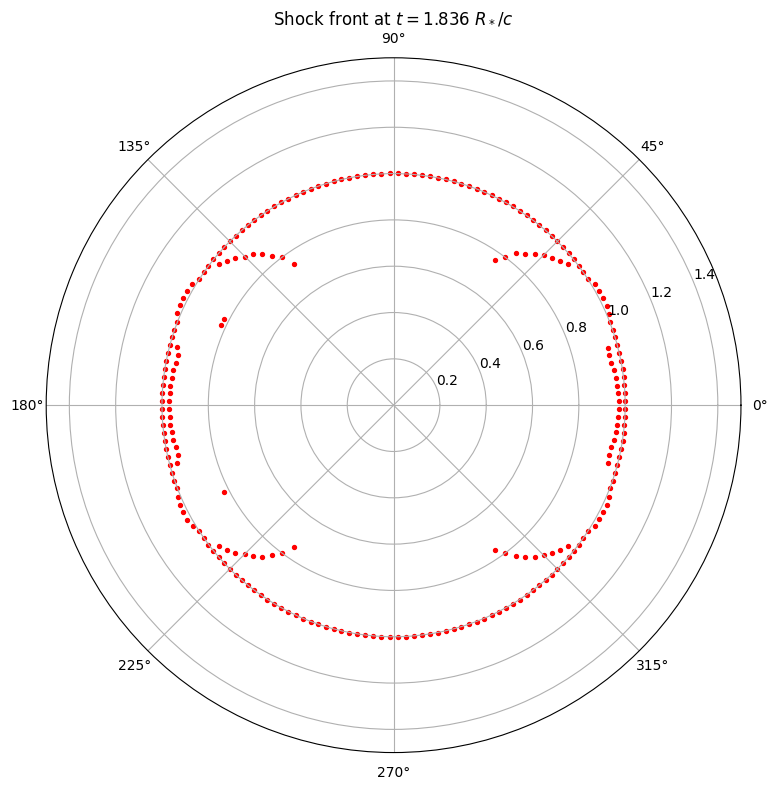

Requested t=1.8538, using t=1.8534  (216 fronts)


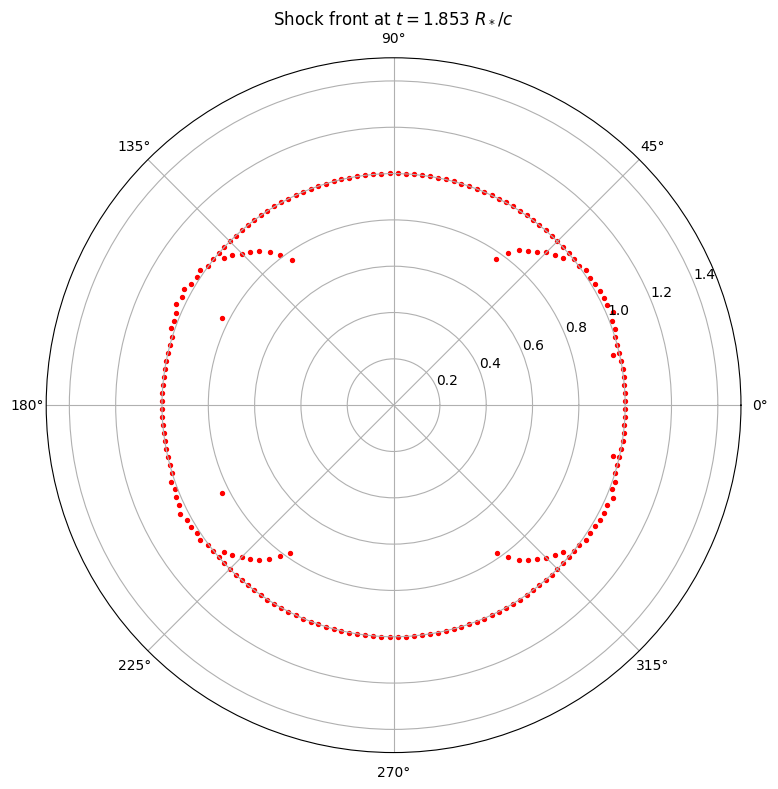

Requested t=1.8718, using t=1.8714  (206 fronts)


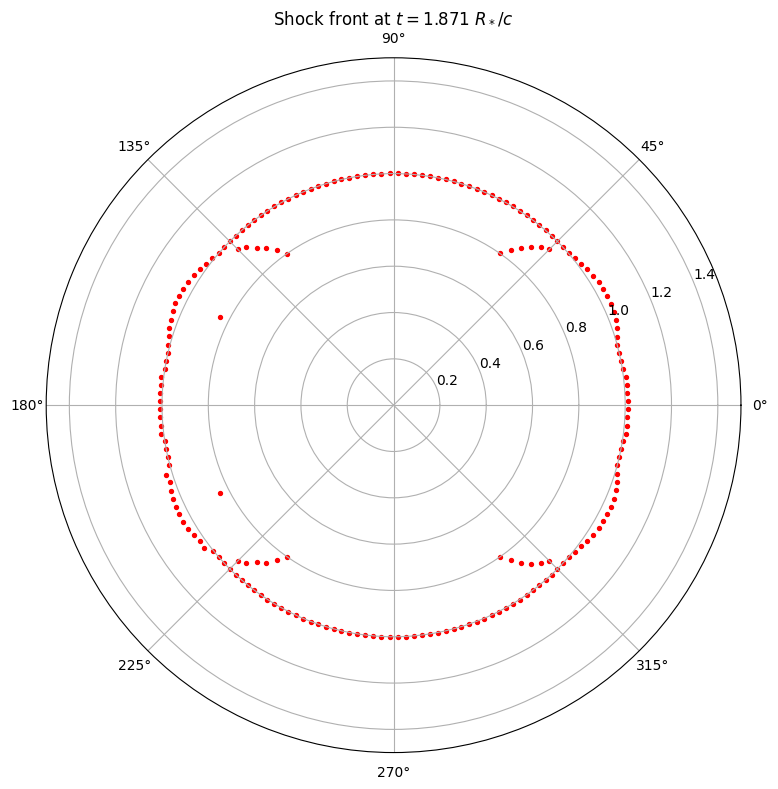

Requested t=1.8897, using t=1.8894  (209 fronts)


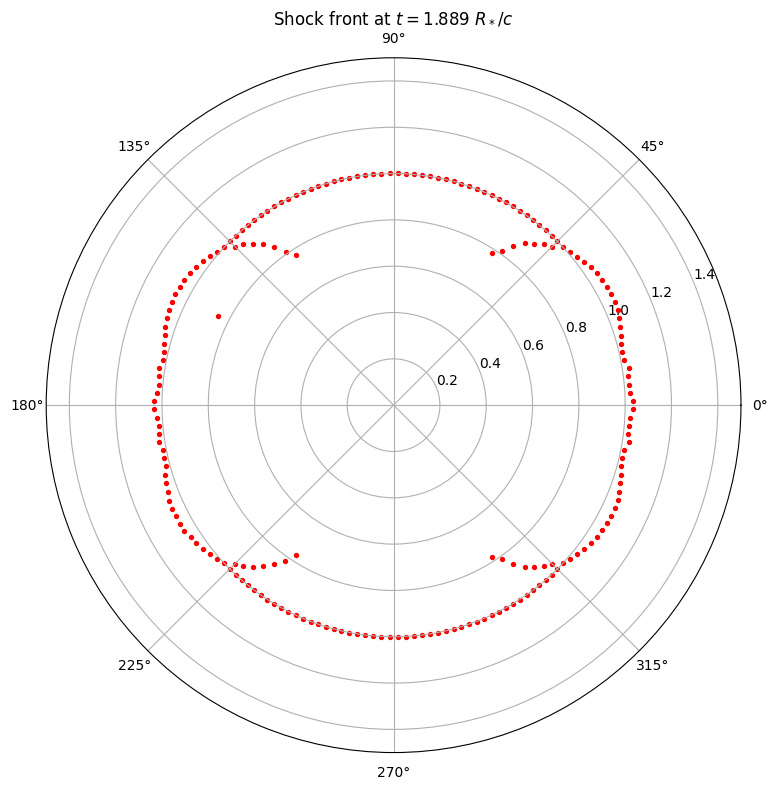

Requested t=1.9077, using t=1.9075  (200 fronts)


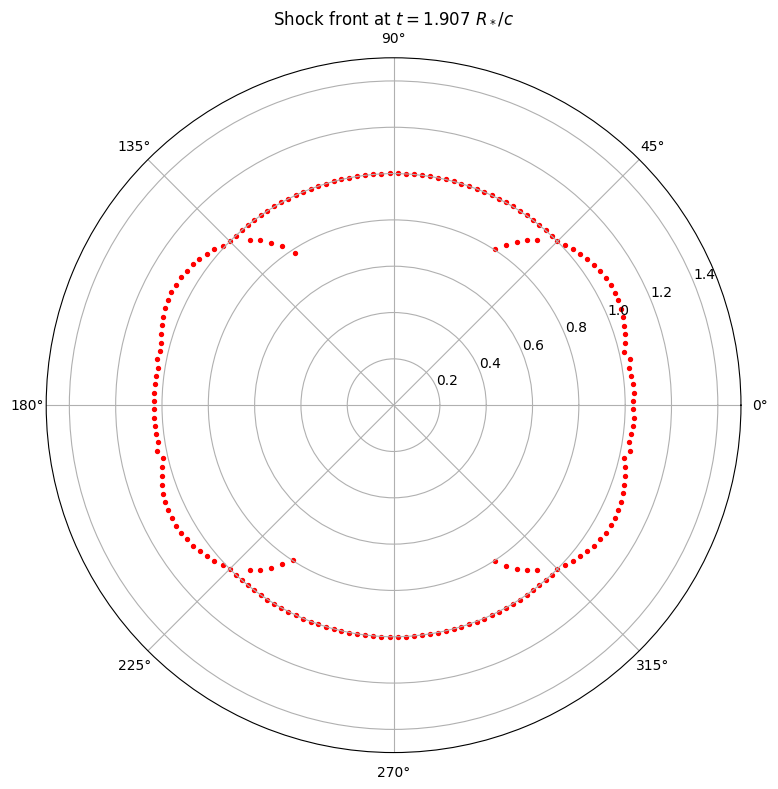

Requested t=1.9256, using t=1.9255  (200 fronts)


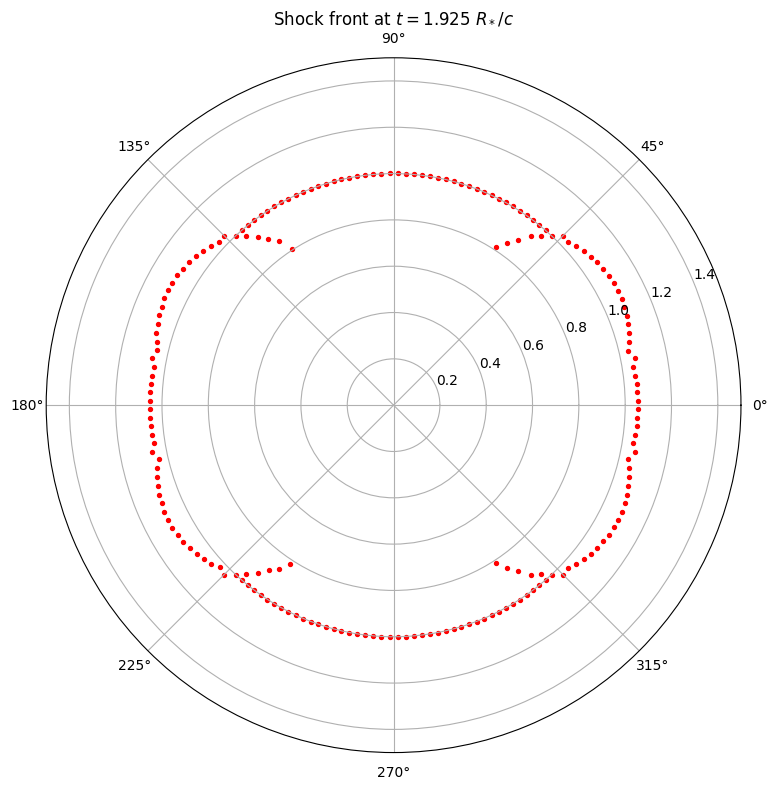

Requested t=1.9436, using t=1.9435  (201 fronts)


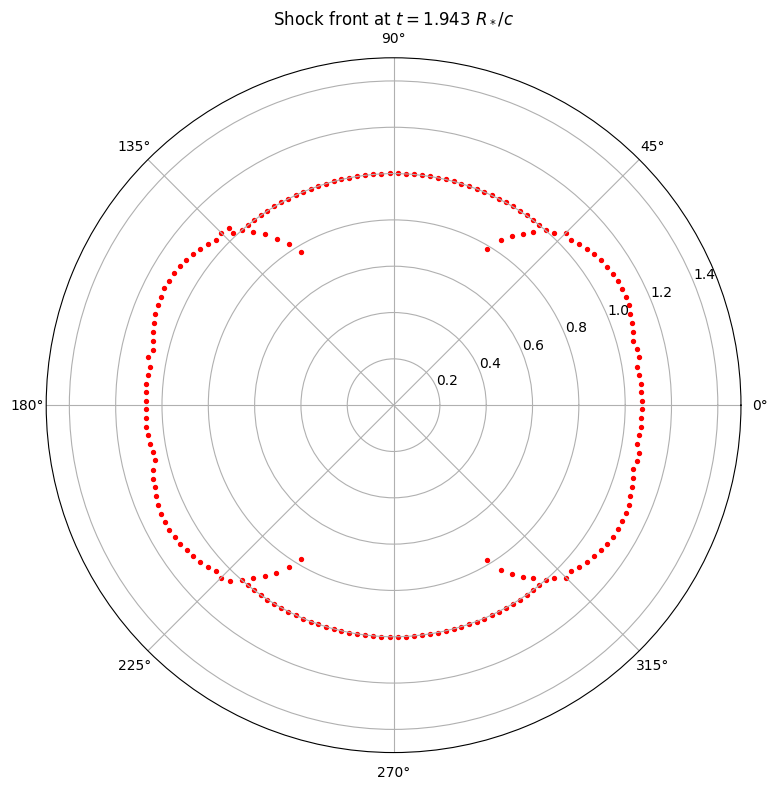

Requested t=1.9615, using t=1.9615  (196 fronts)


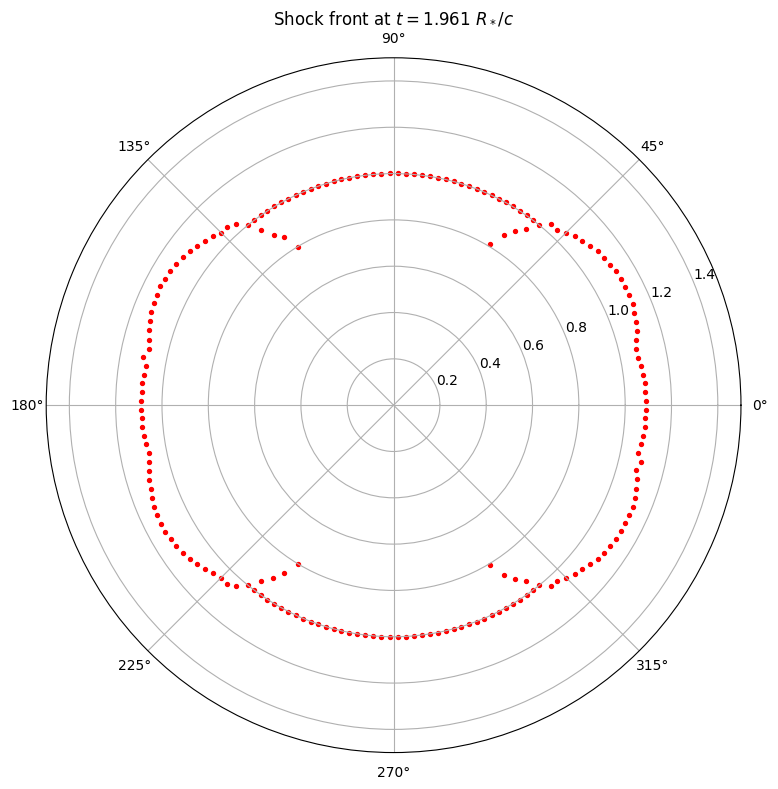

Requested t=1.9795, using t=1.9795  (201 fronts)


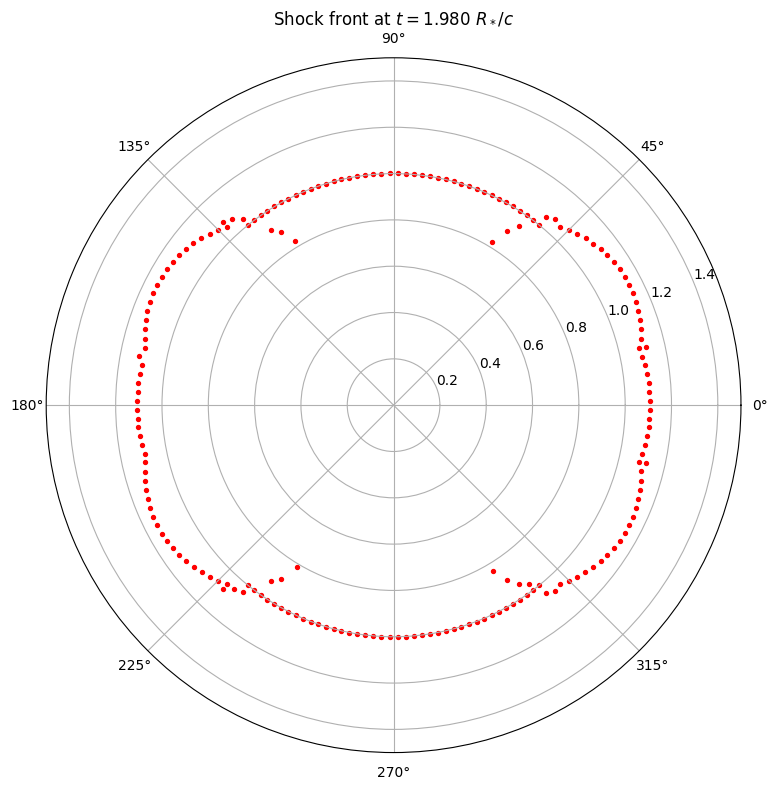

Requested t=1.9974, using t=1.9975  (204 fronts)


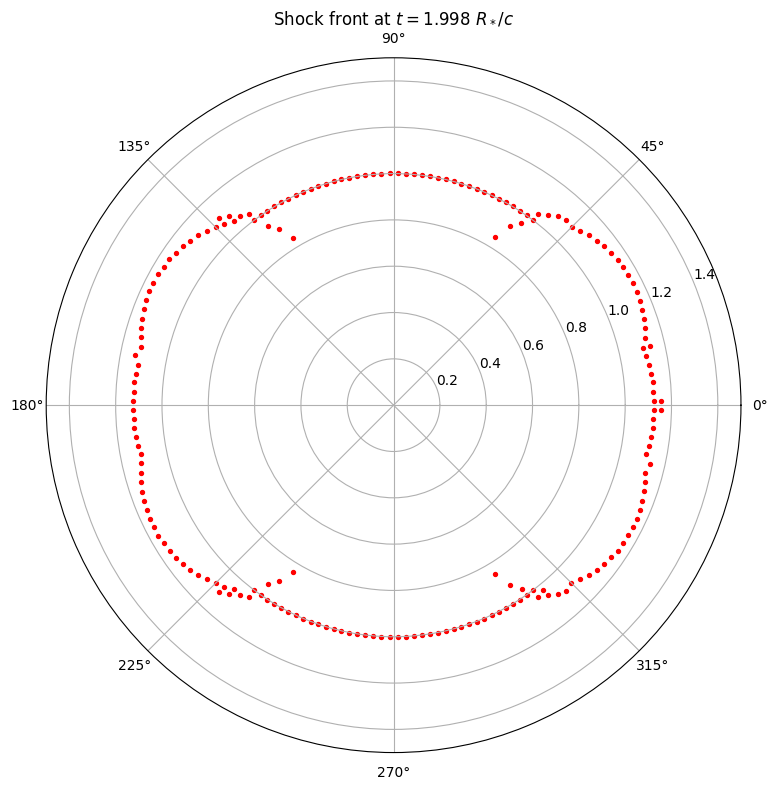

Requested t=2.0154, using t=2.0155  (205 fronts)


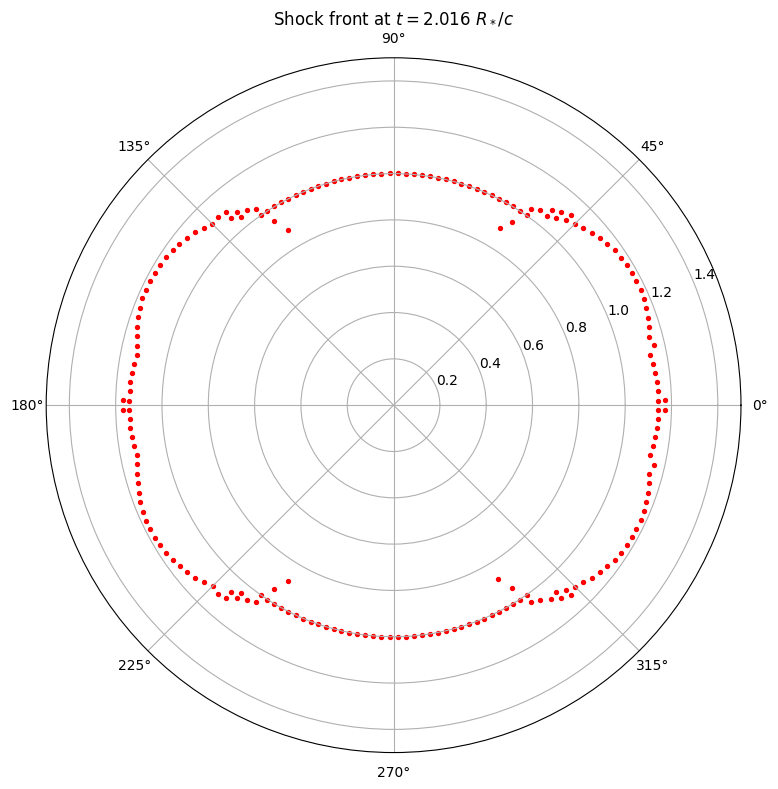

Requested t=2.0333, using t=2.0335  (204 fronts)


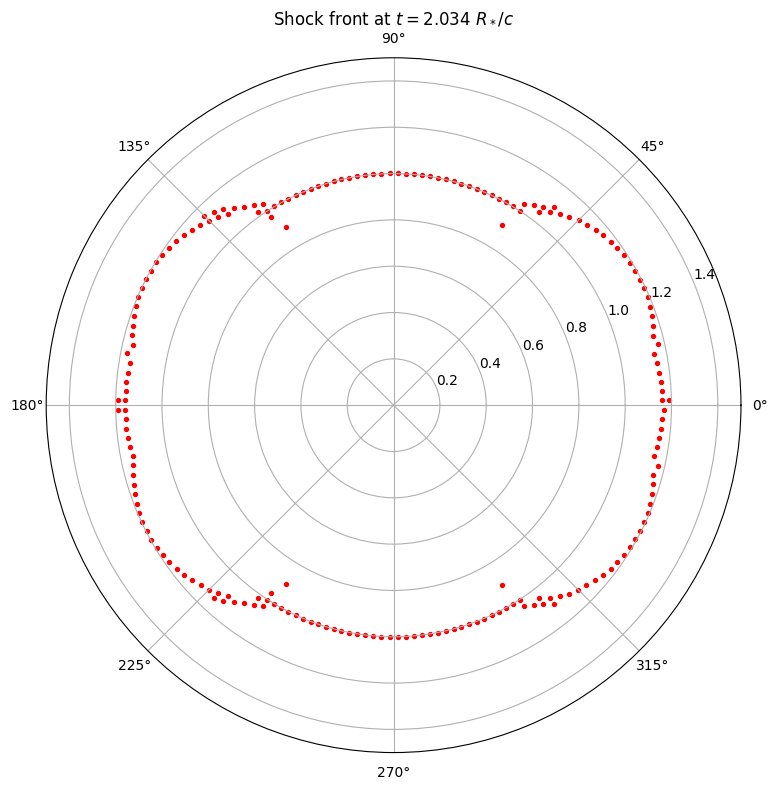

Requested t=2.0513, using t=2.0516  (199 fronts)


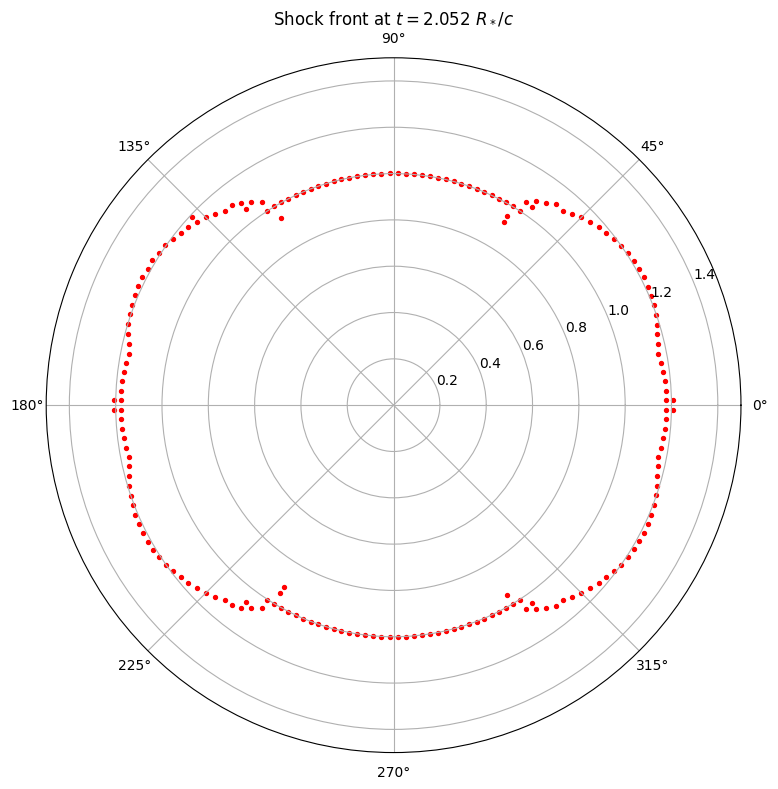

Requested t=2.0692, using t=2.0696  (213 fronts)


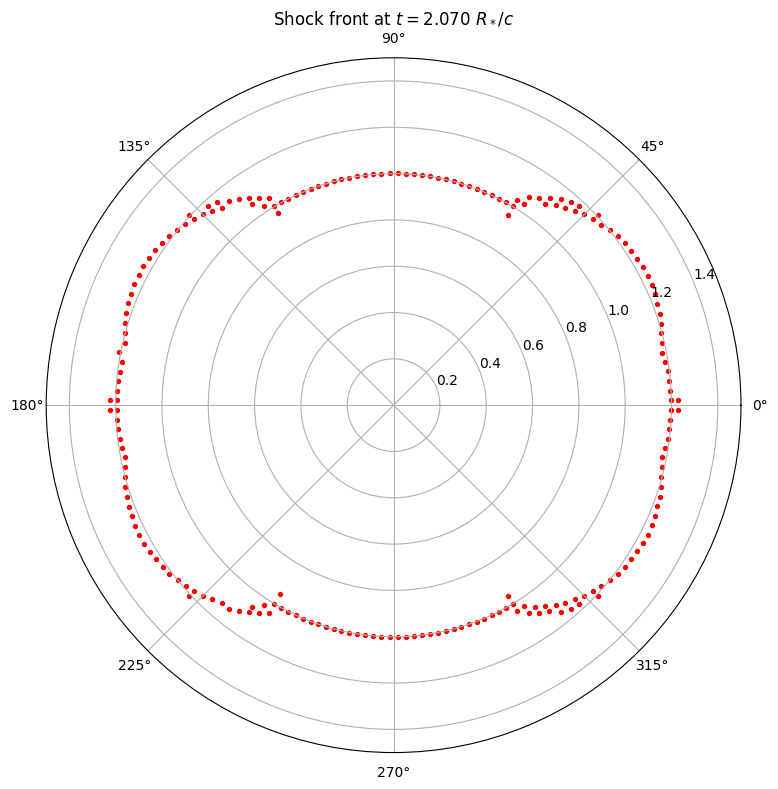

Requested t=2.0872, using t=2.0876  (213 fronts)


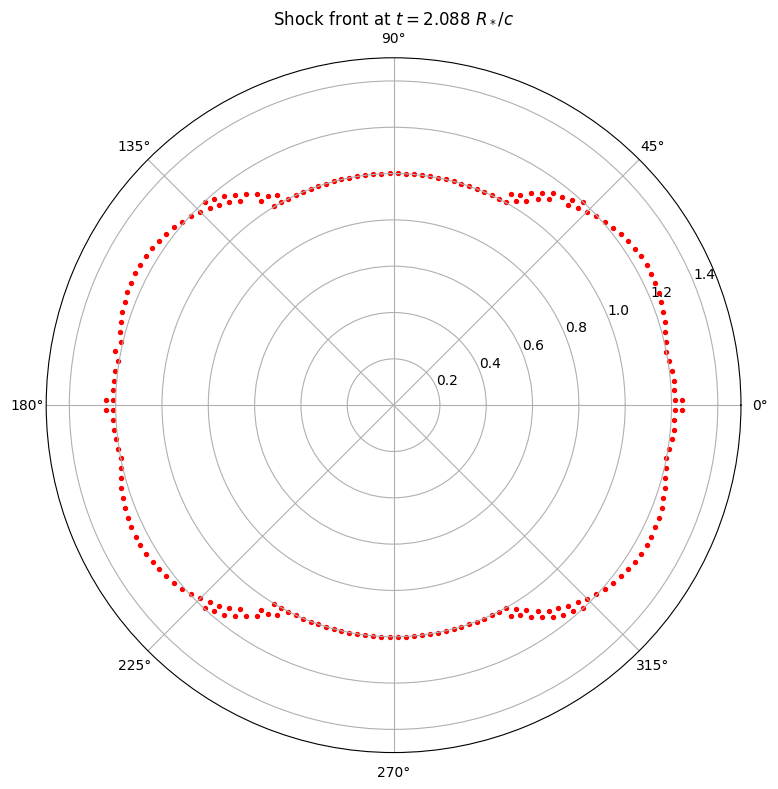

Requested t=2.1051, using t=2.1056  (212 fronts)


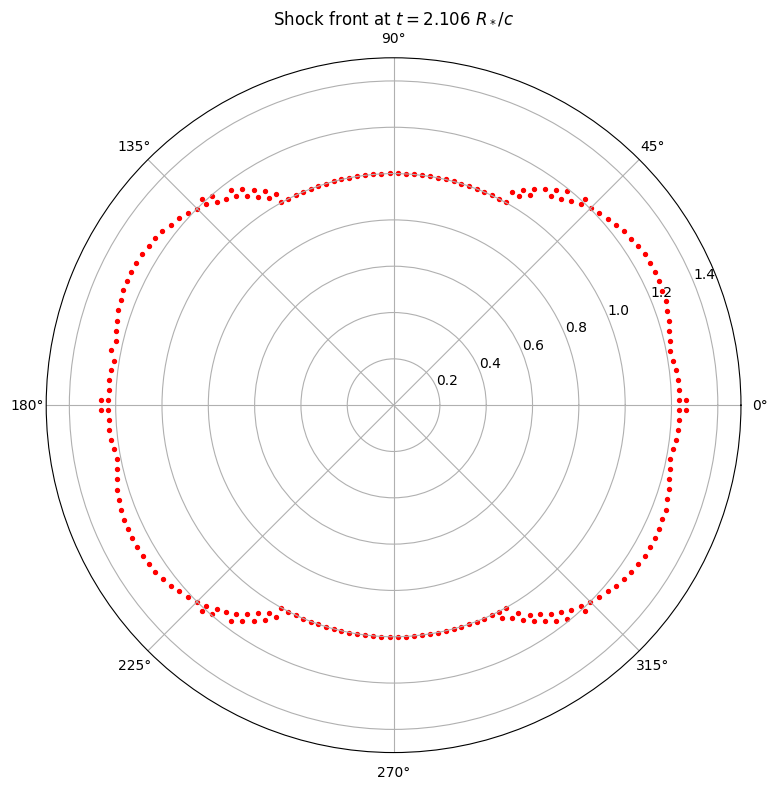

Requested t=2.1231, using t=2.1226  (216 fronts)


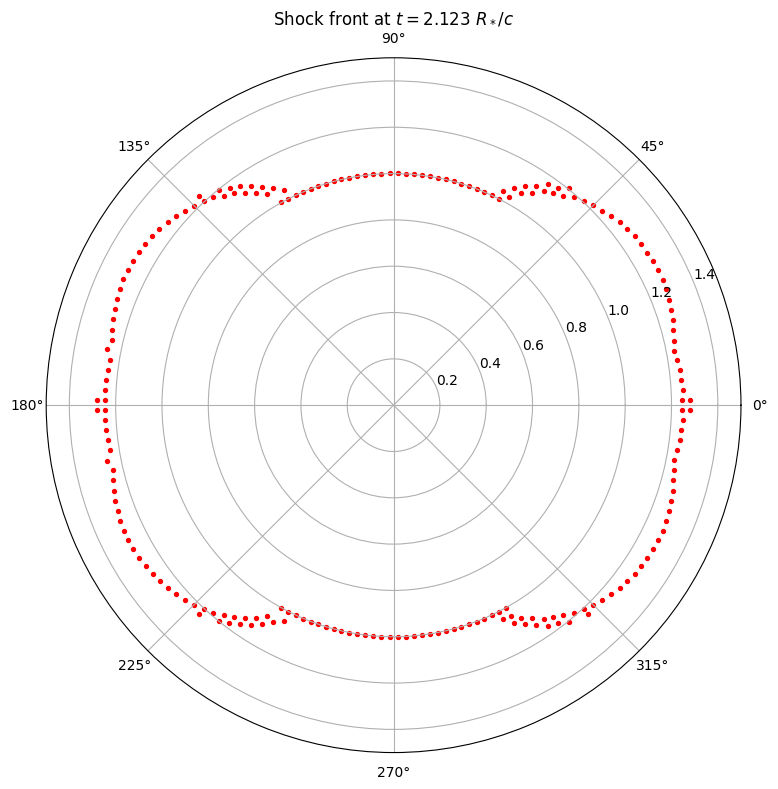

Requested t=2.1410, using t=2.1406  (213 fronts)


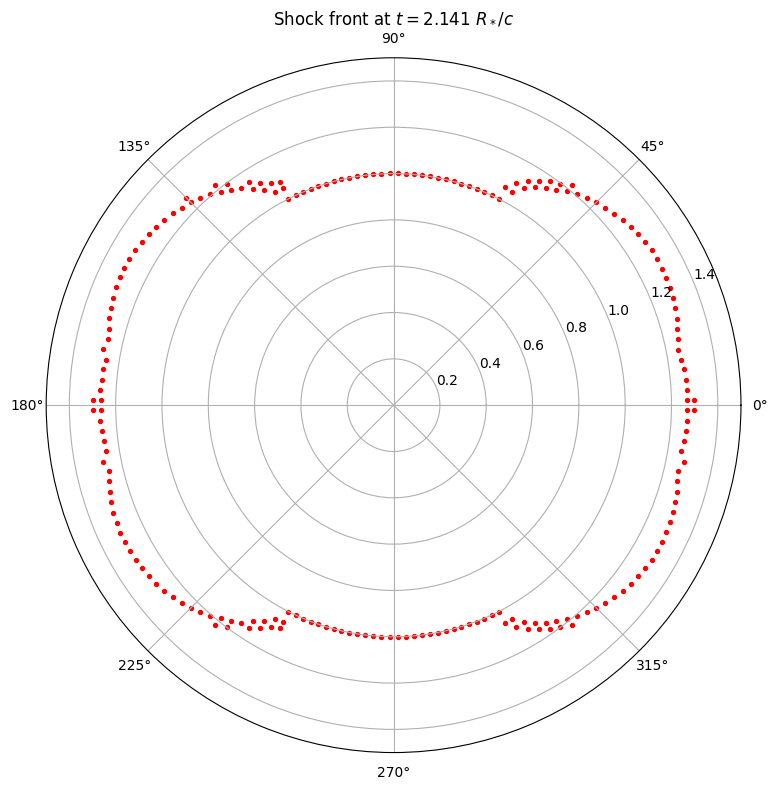

Requested t=2.1590, using t=2.1586  (221 fronts)


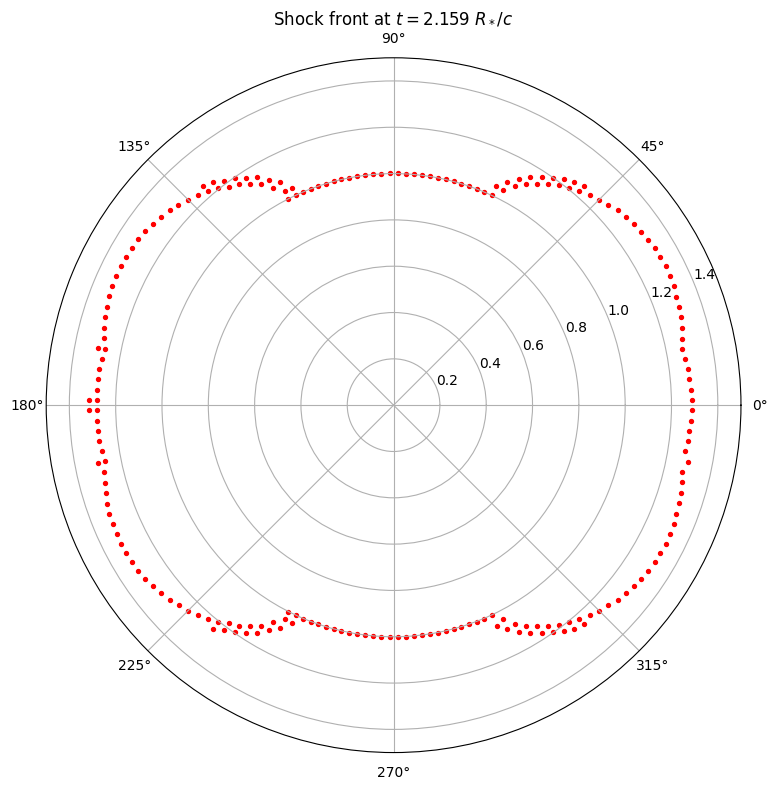

Requested t=2.1769, using t=2.1766  (230 fronts)


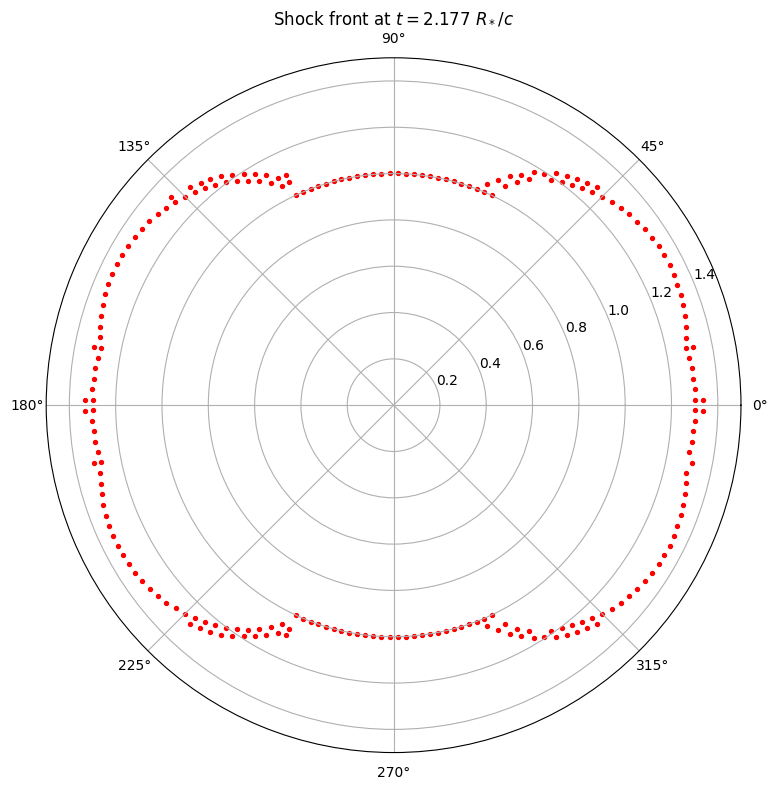

Requested t=2.1949, using t=2.1947  (238 fronts)


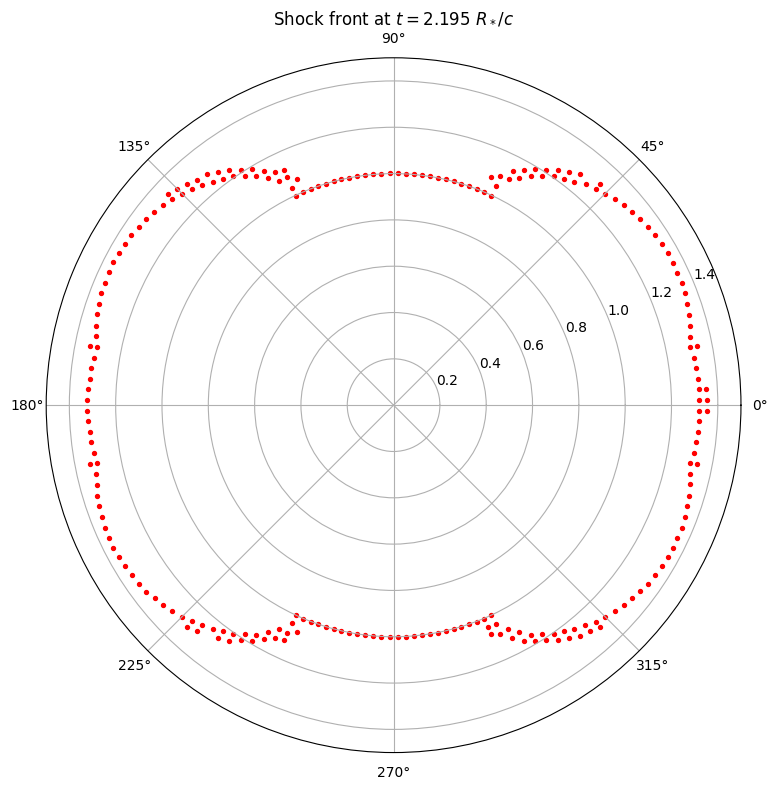

Requested t=2.2128, using t=2.2127  (242 fronts)


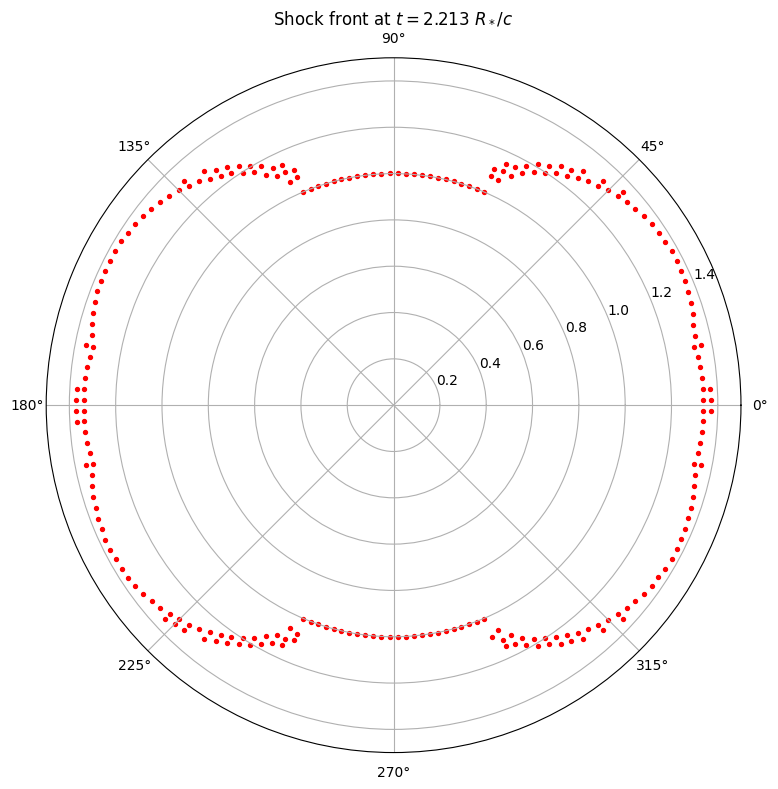

Requested t=2.2308, using t=2.2307  (234 fronts)


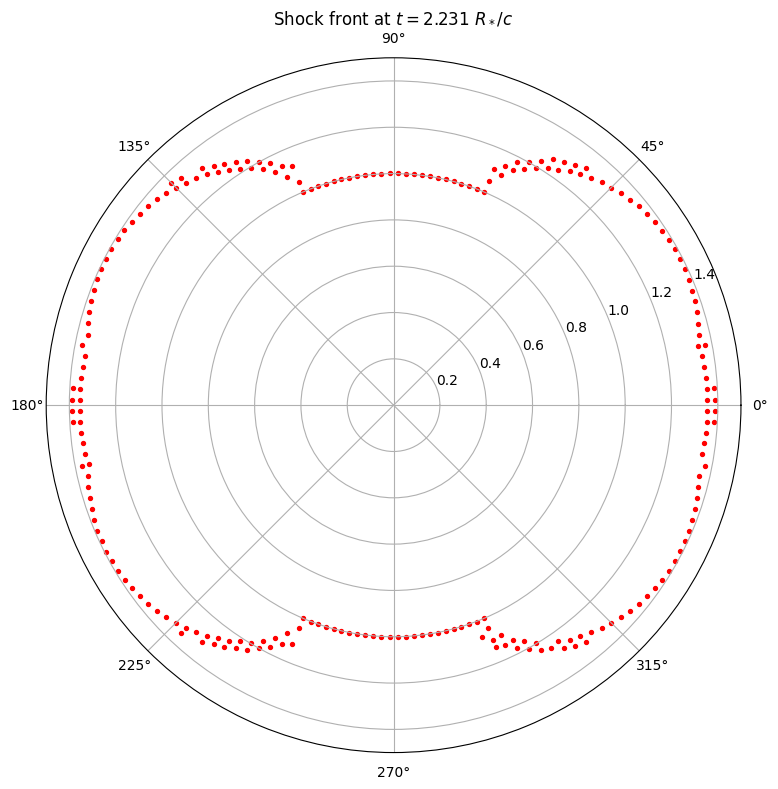

Requested t=2.2487, using t=2.2487  (237 fronts)


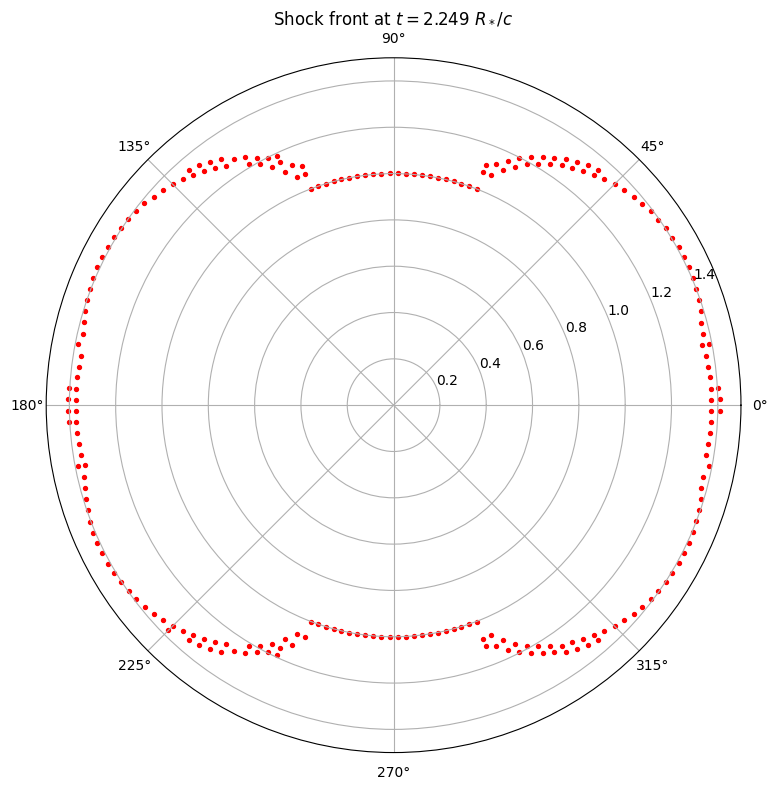

Requested t=2.2667, using t=2.2667  (250 fronts)


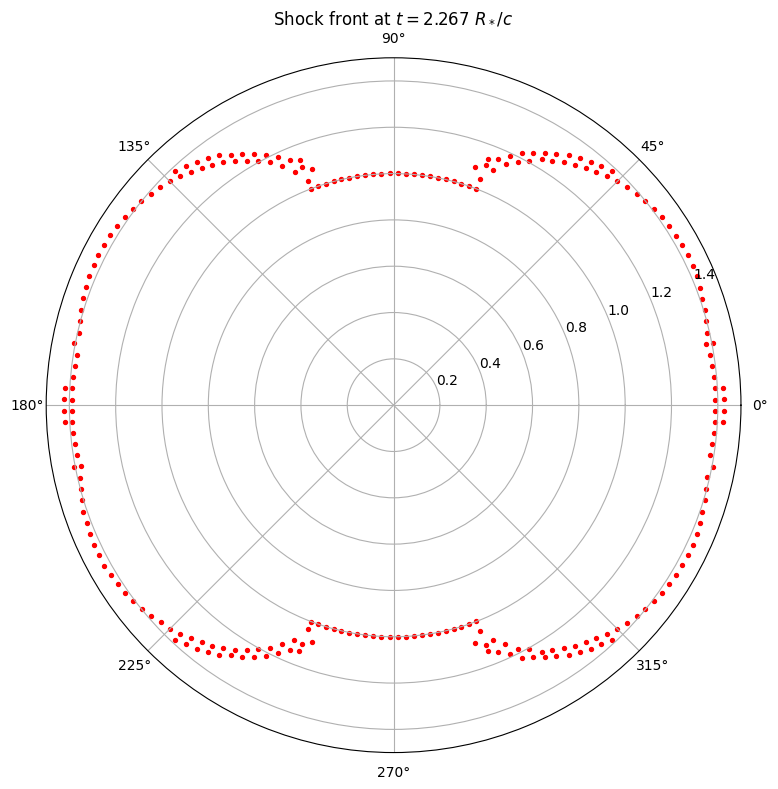

Requested t=2.2846, using t=2.2847  (244 fronts)


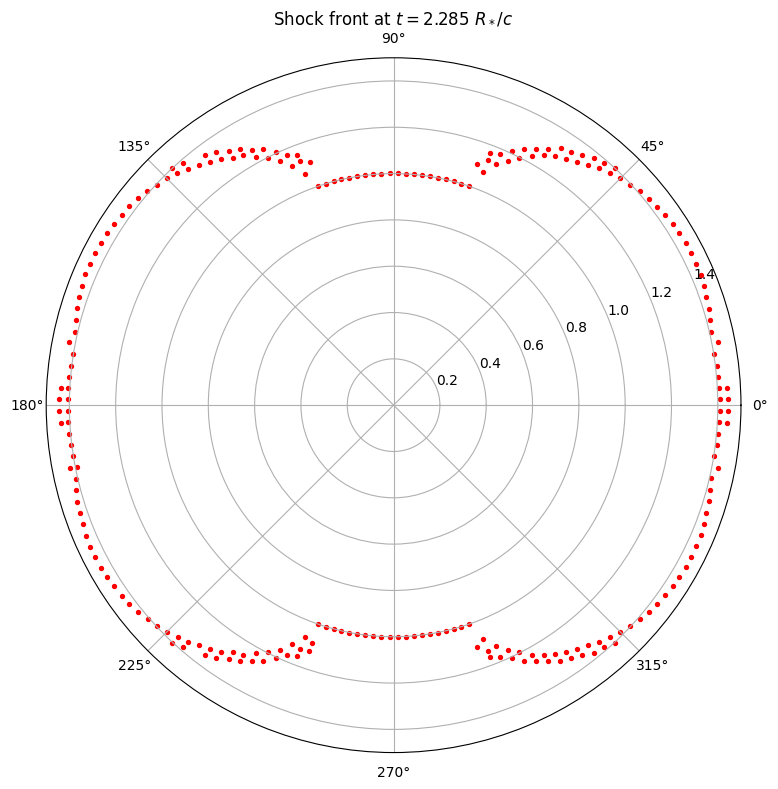

Requested t=2.3026, using t=2.3028  (252 fronts)


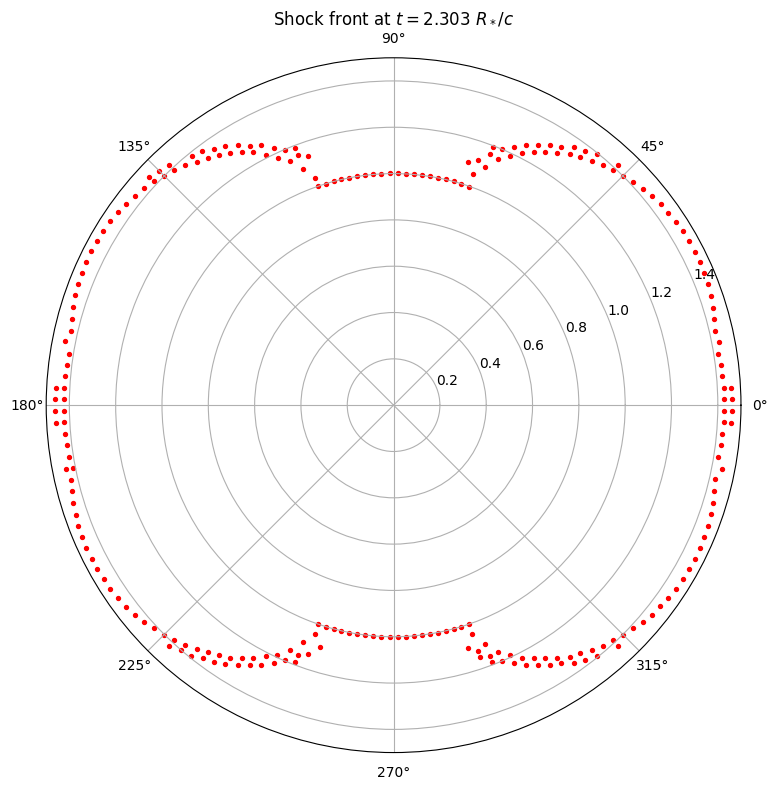

Requested t=2.3205, using t=2.3208  (249 fronts)


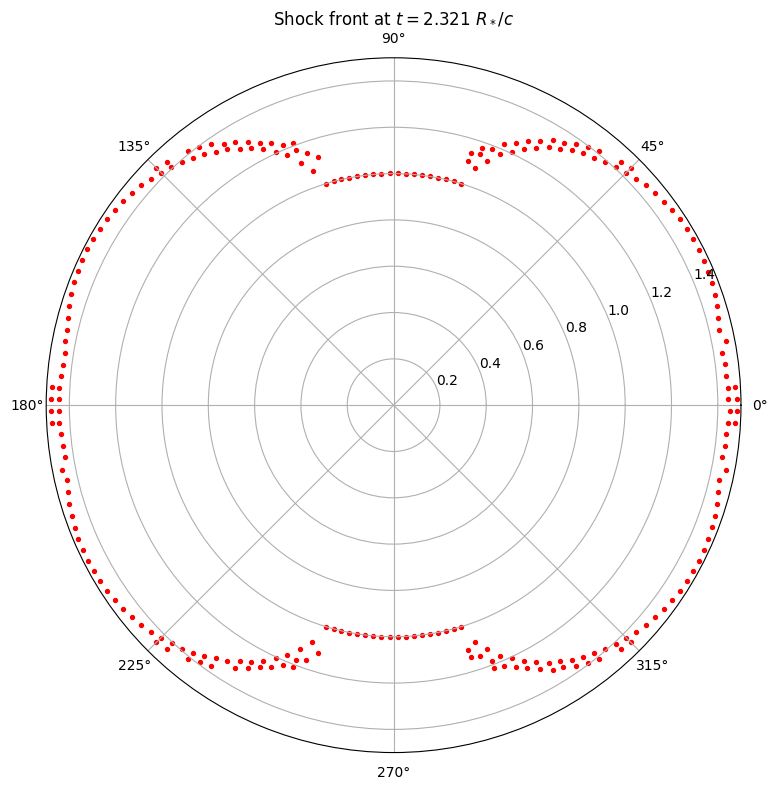

Requested t=2.3385, using t=2.3388  (256 fronts)


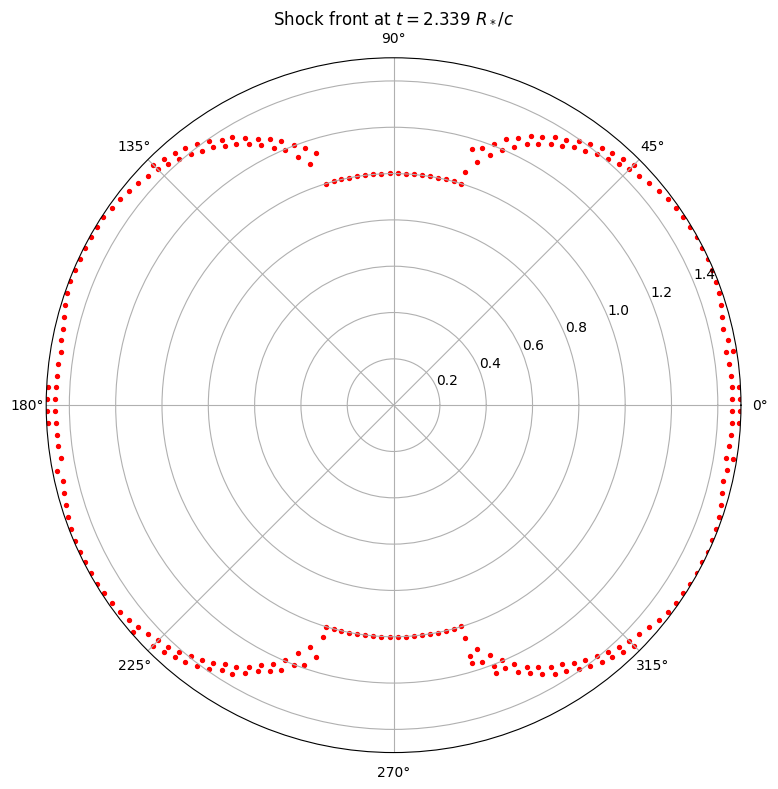

Requested t=2.3564, using t=2.3568  (282 fronts)


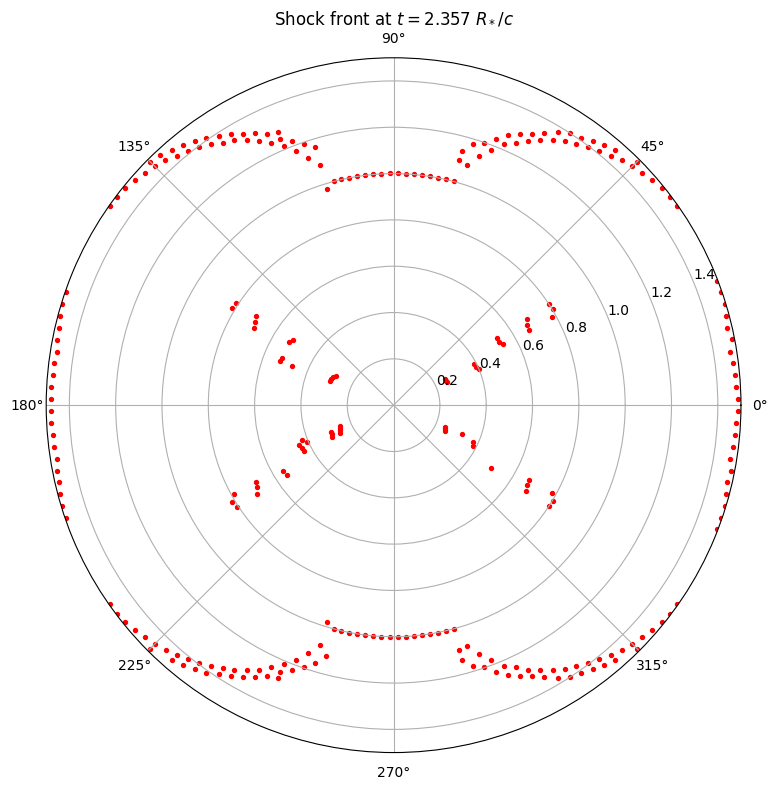

Requested t=2.3744, using t=2.3748  (308 fronts)


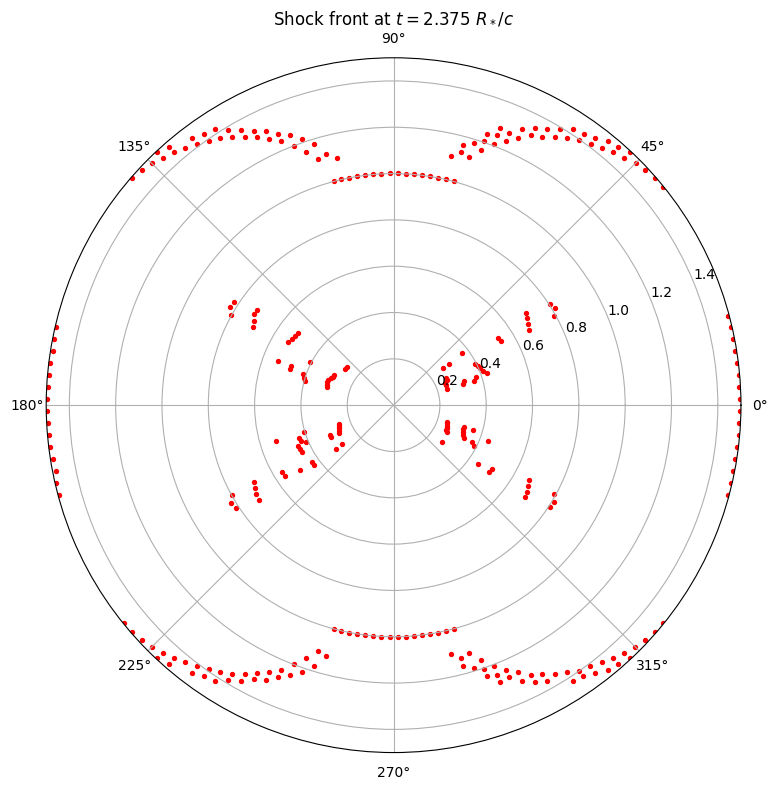

Requested t=2.3923, using t=2.3918  (365 fronts)


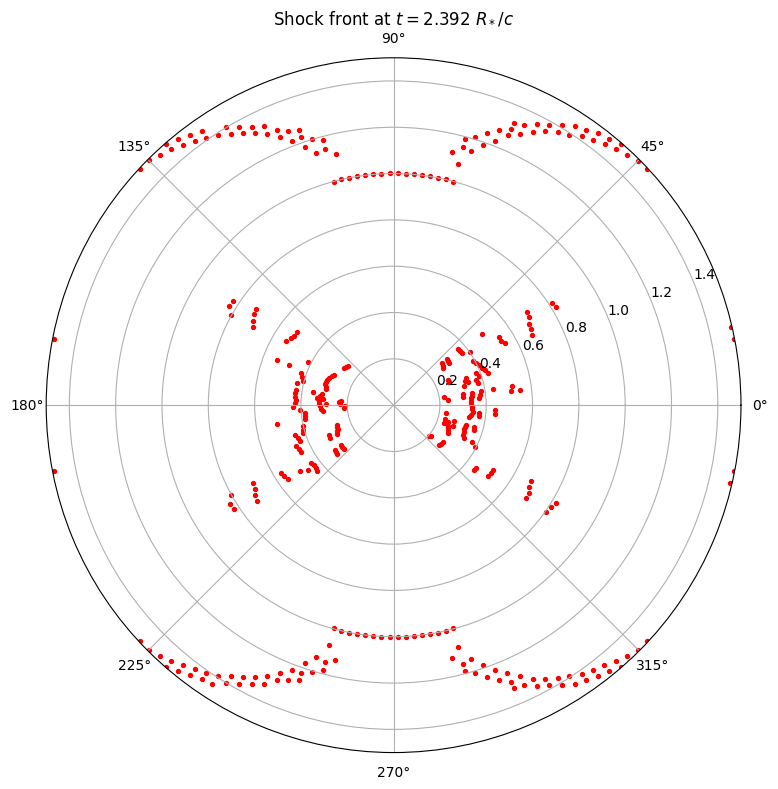

Requested t=2.4103, using t=2.4098  (384 fronts)


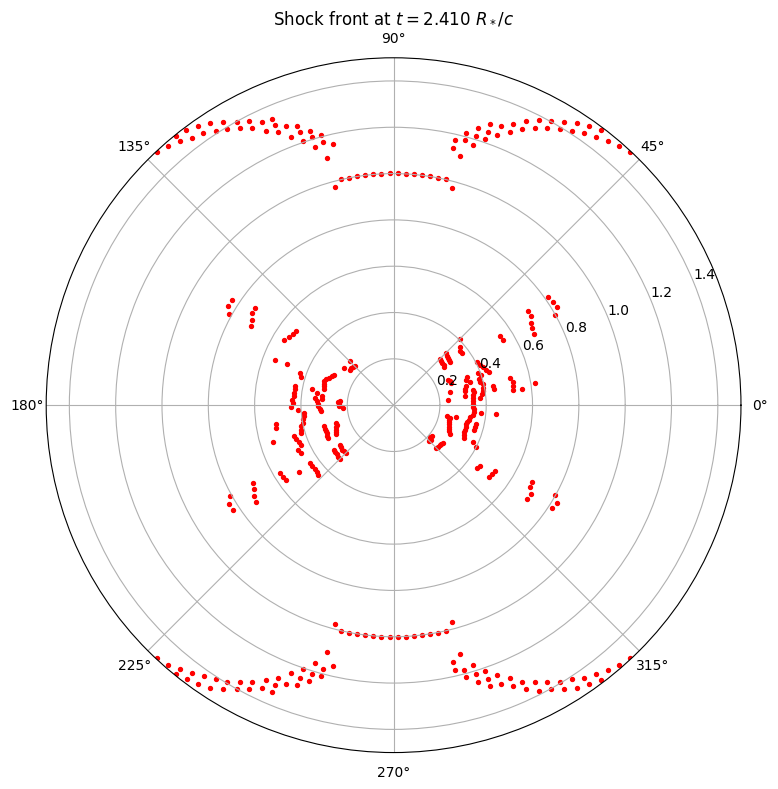

Requested t=2.4282, using t=2.4278  (380 fronts)


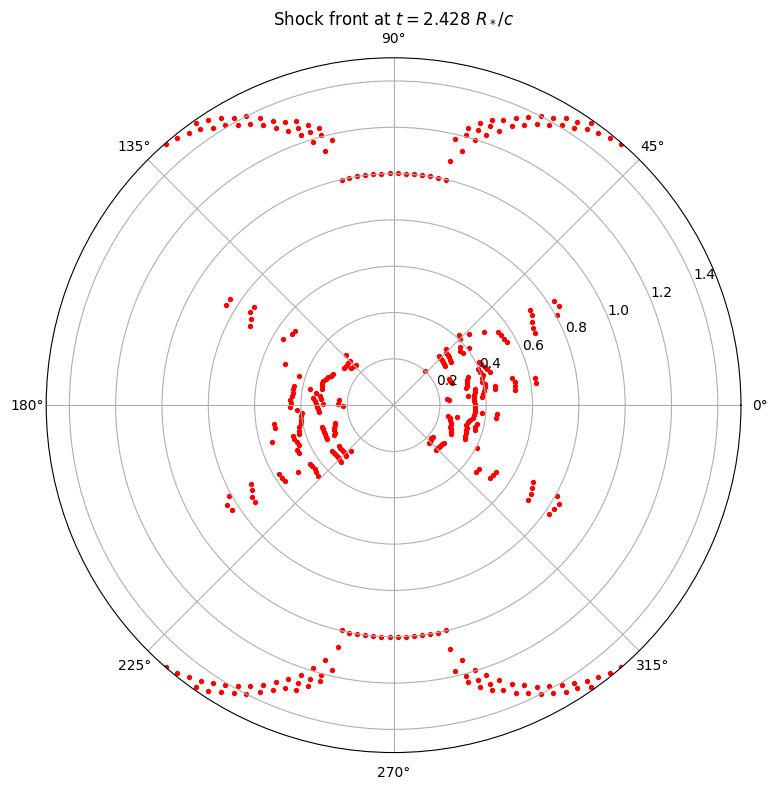

Requested t=2.4462, using t=2.4459  (387 fronts)


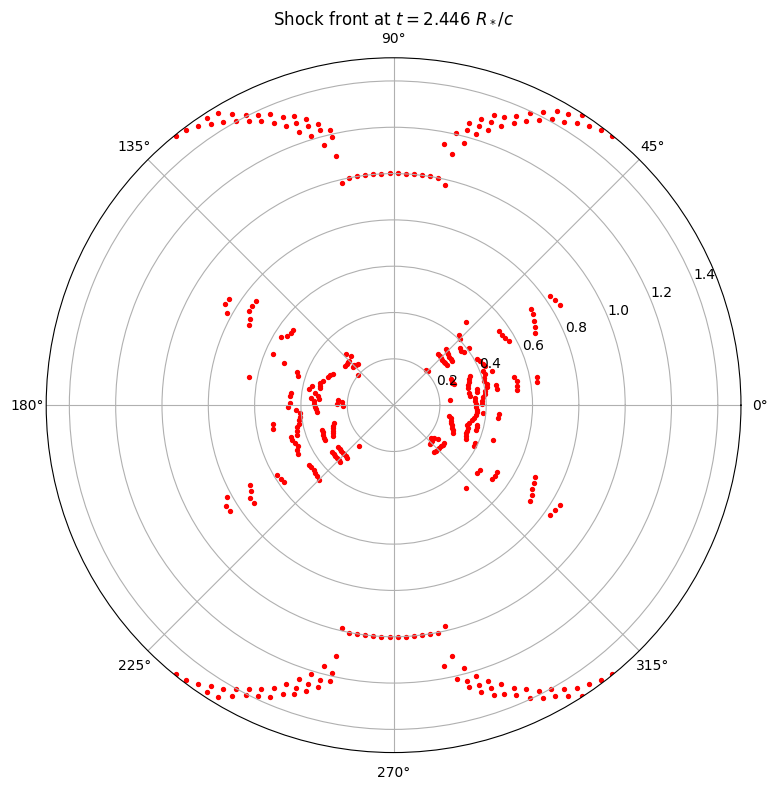

Requested t=2.4641, using t=2.4639  (385 fronts)


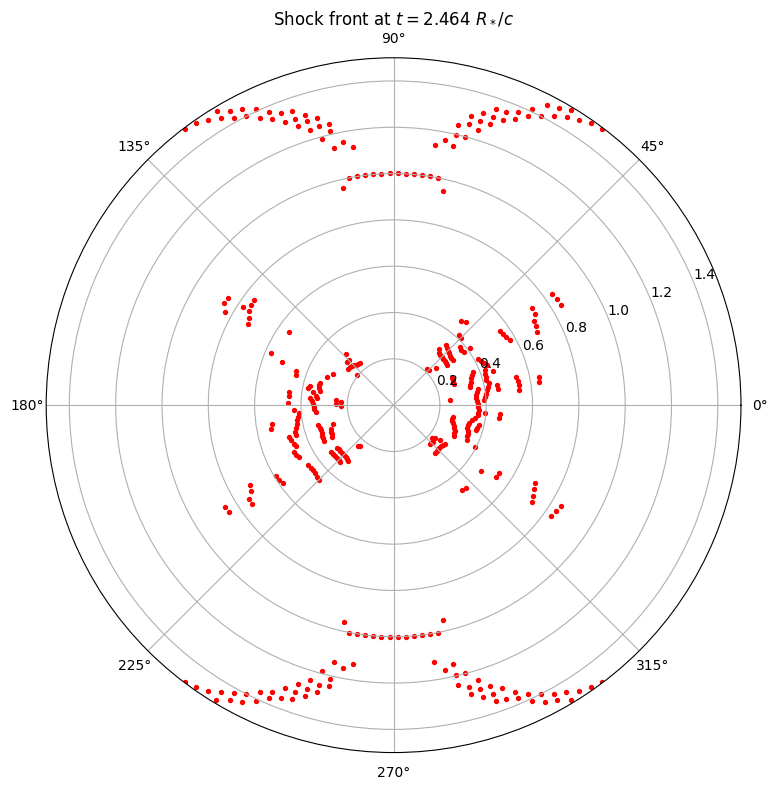

Requested t=2.4821, using t=2.4819  (387 fronts)


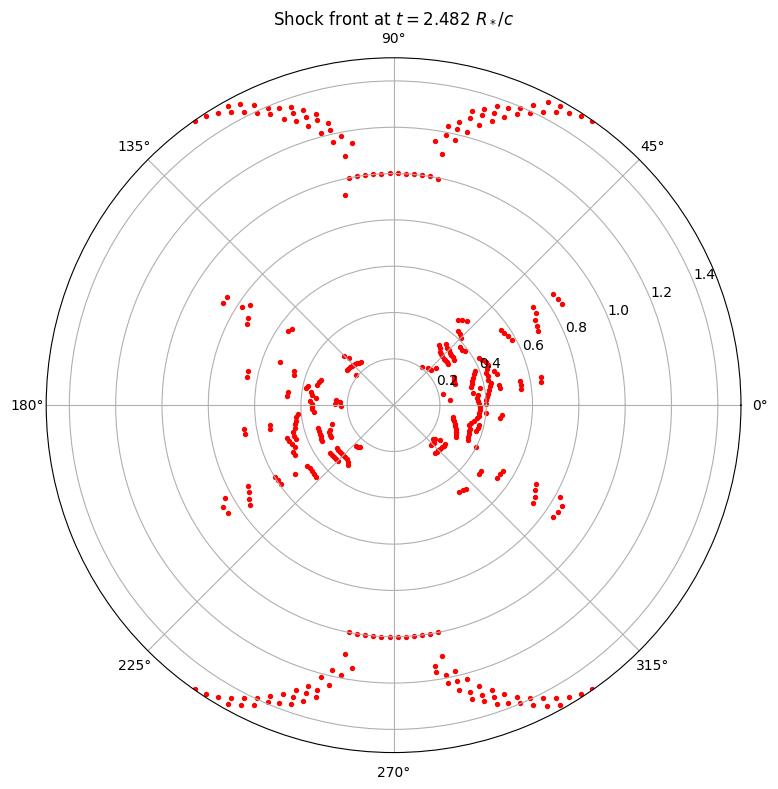

Requested t=2.5000, using t=2.4999  (387 fronts)


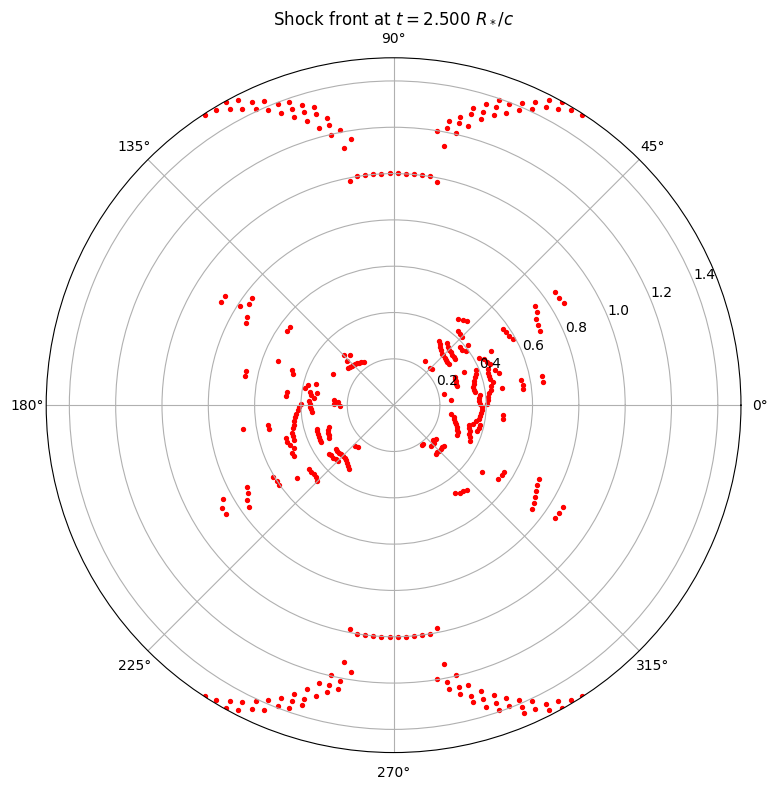

In [7]:
#Now make a movie of the shock front evolution
t = np.linspace(1.8, 2.5, 1)
for t in t:
    plot_fronts_at(t)

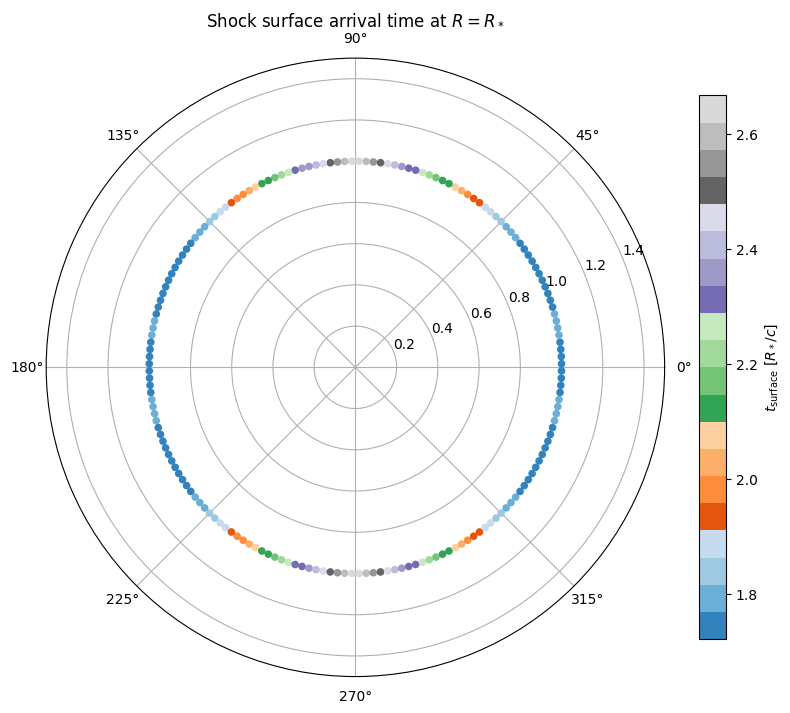

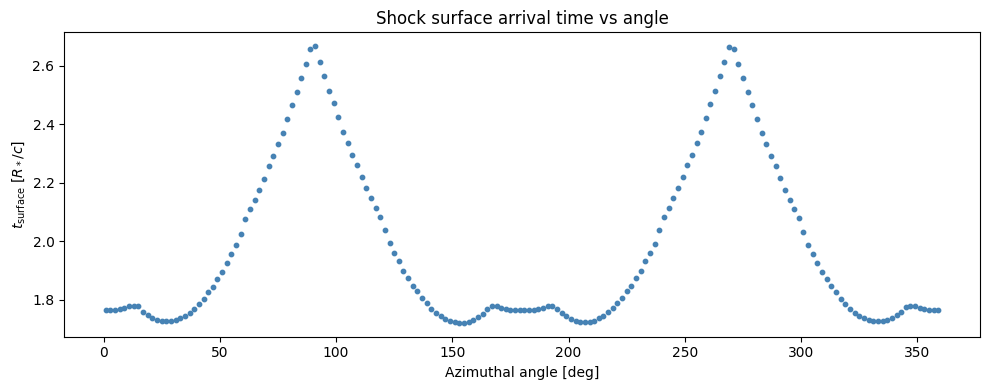

angle_deg
1      1.76434
3      1.76434
5      1.76534
7      1.76734
9      1.77235
11     1.77735
13     1.77935
15     1.77735
17     1.75934
19     1.74833
21     1.73832
23     1.73132
25     1.72731
27     1.72631
29     1.72631
31     1.73031
33     1.73632
35     1.74533
37     1.75633
39     1.77034
41     1.78736
43     1.80437
45     1.82639
47     1.84540
49     1.87142
51     1.89544
53     1.92746
55     1.95549
57     1.98651
59     2.02654
61     2.07758
63     2.11160
65     2.14263
67     2.17665
69     2.21468
71     2.25671
73     2.29274
75     2.33177
77     2.36980
79     2.41784
81     2.46587
83     2.50891
85     2.55894
87     2.60698
89     2.65702
91     2.66703
93     2.61298
95     2.56595
97     2.51491
99     2.47188
101    2.42384
103    2.37480
105    2.33677
107    2.29674
109    2.26172
111    2.21969
113    2.18066
115    2.14663
117    2.11561
119    2.08158
121    2.03855
123    1.99451
125    1.96049
127    1.93147
129    1.89944
131    1.87542


In [8]:
def shock_surface_arrival(r_tol=0.1, vr_min=0.01):
    """
    For each angular bin, find the first timestep where a shock front
    sits near R=1 with a meaningful outward radial velocity.

    r_tol  : half-window around R=1 to count as 'at the surface' [R_*]
    vr_min : minimum u^r (4-velocity) to exclude near-zero background
              (at t=0 the stellar surface already has a gradient peak but u^r~1e-7)
    """
    near_surface = fronts[
        (np.abs(fronts['r_shock'] - 1.0) < r_tol) &
        (fronts['vr'] > vr_min)
    ]
    arrival = (
        near_surface
        .reset_index()
        .groupby('angle_deg')['time']
        .min()
        .rename('t_surface')
    )
    return arrival

arrival = shock_surface_arrival(r_tol=0.1, vr_min=0.01)

# Polar plot: each angle dot coloured by arrival time
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
sc = ax.scatter(
    np.deg2rad(arrival.index), np.ones(len(arrival)),
    c=arrival.values, cmap='tab20c', s=20, zorder=3
)
ax.set_rlim(0, 1.5)
ax.set_title(r"Shock surface arrival time at $R = R_*$")
plt.colorbar(sc, ax=ax, label=r'$t_{\rm surface}\ [R_*/c]$', fraction=0.04)
plt.tight_layout()
plt.show()

# Cartesian: angle vs arrival time (easier to read exact values)
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(arrival.index, arrival.values, s=10, c='steelblue')
ax.set_xlabel(r'Azimuthal angle [deg]')
ax.set_ylabel(r'$t_{\rm surface}\ [R_*/c]$')
ax.set_title(r'Shock surface arrival time vs angle')
plt.tight_layout()
plt.show()

print(arrival.to_string())

/tmp/ipykernel_3734954/2388121645.py:20: RuntimeWarning: divide by zero encountered in divide
  pattern_speed = 1.0 / np.abs(dt_dphi)


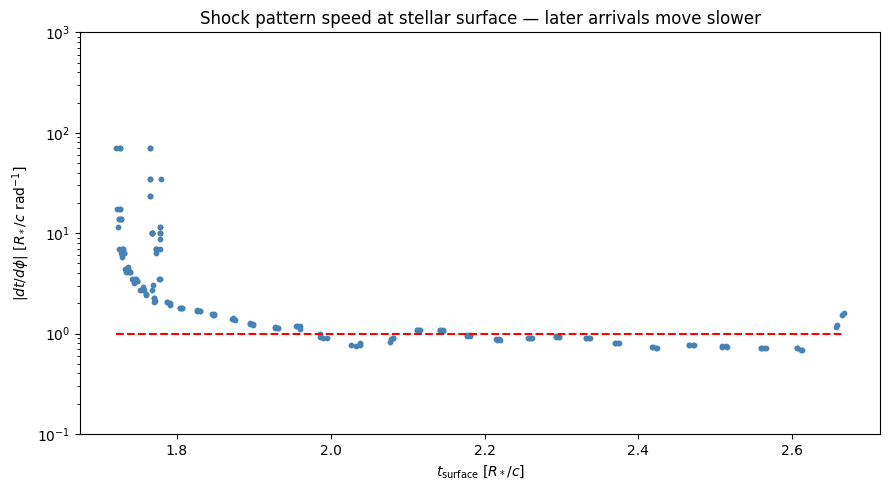

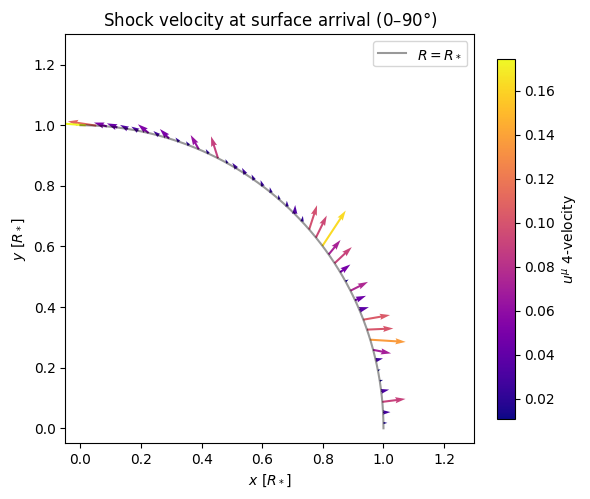

In [14]:
def surface_arrival_rows(r_tol=0.1, vr_min=0.01):
    """Full shock row (including vr, v_tang) at first surface arrival per angle."""
    near = (
        fronts[
            (np.abs(fronts['r_shock'] - 1.0) < r_tol) &
            (fronts['vr'] > vr_min)
        ]
        .reset_index()
        .sort_values('time')
    )
    return near.groupby('angle_deg').first().reset_index()

arr = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
phi_rad = np.deg2rad(arr['angle_deg'].values)
t_surf  = arr['time'].values

# ---- 1. Pattern speed: t_surface vs 1/speed = dt/dphi ----
dt_dphi = np.gradient(t_surf, phi_rad)          # [R_*/c per rad]
# at R=1 the linear pattern speed along the surface is dphi/dt [c]
pattern_speed = 1.0 / np.abs(dt_dphi)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(t_surf, pattern_speed, s=10, c='steelblue')
ax.set_yscale('log')
ax.set_ylim(0.1, 1e3)
ax.set_xlabel(r'$t_{\rm surface}\ [R_*/c]$')
ax.set_ylabel(r'$|dt/d\phi|\ [R_*/c\ \mathrm{rad}^{-1}]$')
ax.set_title(r'Shock pattern speed at stellar surface — later arrivals move slower')
ax.hlines(1.0, t_surf.min(), t_surf.max(), colors='red', linestyles='dashed', label='Speed of Light')
plt.tight_layout()
plt.show()

# ---- 2. Velocity quivers at surface, 0–90° only ----
q = arr[(arr['angle_deg'] >= 0) & (arr['angle_deg'] <= 90)].copy()
phi_q = np.deg2rad(q['angle_deg'].values)

# Position on unit circle
x_pos = np.cos(phi_q)
y_pos = np.sin(phi_q)

# Decompose into Cartesian: e_r = (cosφ, sinφ), e_φ = (−sinφ, cosφ)
vr  = q['vr'].values
vt  = q['v_tang'].values
vx  = vr * np.cos(phi_q) - vt * np.sin(phi_q)
vy  = vr * np.sin(phi_q) + vt * np.cos(phi_q)
spd = np.sqrt(vx**2 + vy**2)

# Scale so the fastest arrow is 0.15 R_* long
arrow_scale = 0.15 / spd.max() if spd.max() > 0 else 1.0


fig, ax = plt.subplots(figsize=(6, 6))
theta_arc = np.linspace(0, np.pi/2, 300)
ax.plot(np.cos(theta_arc), np.sin(theta_arc), 'k-', lw=1.5, alpha=0.4, label=r'$R = R_*$')
qv = ax.quiver(
    x_pos, y_pos,
    vx * arrow_scale, vy * arrow_scale,
    spd, cmap='plasma',
    angles='xy', scale_units='xy', scale=1,
    width=0.005, clim=(spd.min(), spd.max())
)
plt.colorbar(qv, ax=ax, label=r'$u^\mu$ 4-velocity', fraction=0.04)
ax.set_xlim(-0.05, 1.3)
ax.set_ylim(-0.05, 1.3)
ax.set_aspect('equal')
ax.set_xlabel(r'$x\ [R_*]$')
ax.set_ylabel(r'$y\ [R_*]$')
ax.set_title(r'Shock velocity at surface arrival ($0$–$90°$)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

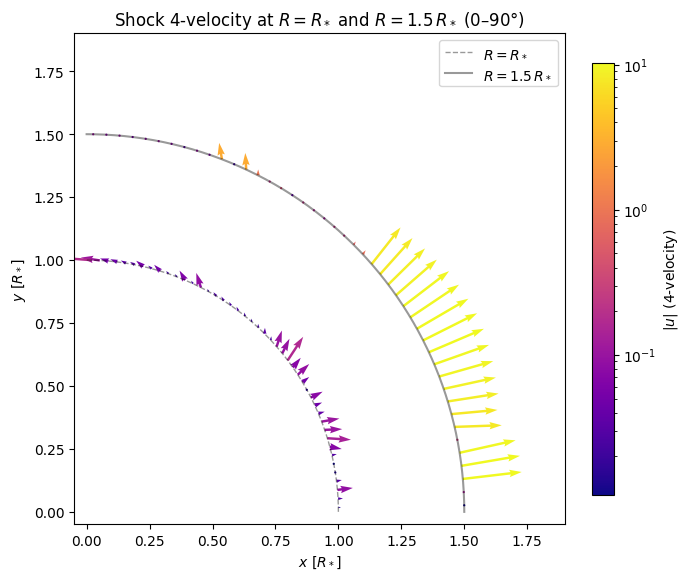

In [16]:
import matplotlib.colors as mcolors

def boundary_arrival_rows(r_tol=0.05, vr_min=0.01):
    """Full shock row (including vr, v_tang) at first R=1.5 boundary arrival per angle."""
    near = (
        fronts[
            (np.abs(fronts['r_shock'] - 1.5) < r_tol) &
            (fronts['vr'] > vr_min)
        ]
        .reset_index()
        .sort_values('time')
    )
    return near.groupby('angle_deg').first().reset_index()

# --- Surface arrival (R=1) ---
arr_surf = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
q_surf = arr_surf[(arr_surf['angle_deg'] >= 0) & (arr_surf['angle_deg'] <= 90)].copy()
phi_surf = np.deg2rad(q_surf['angle_deg'].values)
x_surf = np.cos(phi_surf)
y_surf = np.sin(phi_surf)
vr_s  = q_surf['vr'].values
vt_s  = q_surf['v_tang'].values
vx_s  = vr_s * np.cos(phi_surf) - vt_s * np.sin(phi_surf)
vy_s  = vr_s * np.sin(phi_surf) + vt_s * np.cos(phi_surf)
spd_s = np.sqrt(vx_s**2 + vy_s**2)

# --- Boundary arrival (R=1.5) ---
arr = boundary_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
q = arr[(arr['angle_deg'] >= 0) & (arr['angle_deg'] <= 90)].copy()
phi_q = np.deg2rad(q['angle_deg'].values)
x_pos = 1.5 * np.cos(phi_q)
y_pos = 1.5 * np.sin(phi_q)
vr  = q['vr'].values
vt  = q['v_tang'].values
vx  = vr * np.cos(phi_q) - vt * np.sin(phi_q)
vy  = vr * np.sin(phi_q) + vt * np.cos(phi_q)
spd = np.sqrt(vx**2 + vy**2)

# Shared log-scale norm spanning both datasets
spd_min = min(spd_s[spd_s > 0].min(), spd[spd > 0].min())
spd_max = max(spd_s.max(), spd.max())
norm = mcolors.LogNorm(vmin=spd_min, vmax=spd_max)

# Separate arrow scales so both sets are visually legible
arrow_scale_s = 0.12 / spd_s.max() if spd_s.max() > 0 else 1.0
arrow_scale_b = 0.12 / spd.max()   if spd.max()   > 0 else 1.0

theta_arc = np.linspace(0, np.pi/2, 300)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(np.cos(theta_arc), np.sin(theta_arc),
        'k--', lw=1, alpha=0.4, label=r'$R = R_*$')
ax.plot(1.5*np.cos(theta_arc), 1.5*np.sin(theta_arc),
        'k-', lw=1.5, alpha=0.4, label=r'$R = 1.5\,R_*$')

# Surface arrows (R=1)
ax.quiver(
    x_surf, y_surf,
    vx_s * arrow_scale_s, vy_s * arrow_scale_s,
    spd_s, cmap='plasma', norm=norm,
    angles='xy', scale_units='xy', scale=1,
    width=0.005
)

# Boundary arrows (R=1.5)
qv = ax.quiver(
    x_pos, y_pos,
    vx * arrow_scale_b, vy * arrow_scale_b,
    spd, cmap='plasma', norm=norm,
    angles='xy', scale_units='xy', scale=0.5,
    width=0.005
)

plt.colorbar(qv, ax=ax, label=r'$|u|\ \mathrm{(4\text{-}velocity)}$', fraction=0.04)

ax.set_xlim(-0.05, 1.9)
ax.set_ylim(-0.05, 1.9)
ax.set_aspect('equal')
ax.set_xlabel(r'$x\ [R_*]$')
ax.set_ylabel(r'$y\ [R_*]$')
ax.set_title(r'Shock 4-velocity at $R = R_*$ and $R = 1.5\,R_*$ ($0$–$90°$)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Video of the whole thing

In [ ]:
from pathlib import Path
ts = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
nx, ny = ts[0].domain_dimensions[0], ts[0].domain_dimensions[1]
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)

for i, ds in enumerate(ts[800:1100], start=800):
    r_shock_entropy = []  # list of lists: 1 or more radii per theta

    for theta_val in theta_vals:
        ray = ds.ortho_ray(0, (theta_val, z_val))

        df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
        df_entr = df_entr.sort_values('r').reset_index(drop=True)

        if len(df_entr) < 2:
            r_shock_entropy.append([np.nan])
            continue

        # Shock has hit the surface: outer boundary entropy is still unshocked
        if np.log10(df_entr['entropy'].iloc[-1]) < 5:
            r_shock_entropy.append([1.5])
            # print(f"Shock at surface for theta={theta_val:.3f} rad")
            continue

        dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
        abs_grad = np.abs(dlogS_dr)

        peaks, _ = find_peaks(abs_grad, height= 100, distance = 10)
        radii = [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2]

        if radii:
            # print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
            r_shock_entropy.append(radii)
        else:
            r_shock_entropy.append([np.nan])
        # fig, ax = plt.subplots()
        # ax.plot(df_entr['r'], abs_grad, label='Entropy')
        # for r in radii:
        #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
        # ax.set_xlabel(r"$r \ [R_*]$")
        # ax.set_ylabel(r"Entropy $\mathcal{S}$")
        # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds.current_time):.2f}\ R_*/c$") 
        # ax.legend()
        # plt.show()

    # Flatten for polar plot: duplicate theta for entries with two fronts
    plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
    plot_r     = [r  for rs in r_shock_entropy for r in rs]

    plt.figure(figsize=(20, 20))
    plt.polar(plot_theta, plot_r, marker='o', color='g', linestyle='none')
    plt.title(rf"Shock Radius from Entropy Gradient at $t = {float(ds.current_time):.2f}\ R_*/c$")
    plt.savefig(frames_dir / f"frame_{i:04d}.png", dpi=100, bbox_inches='tight')
    plt.close()

In [ ]:
#Now make a video using ffmpeg starting from the first frame frame_1400.png to frame_1499.png
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)
import subprocess
subprocess.run(['ffmpeg', '-y', '-framerate', '10', '-start_number', '800', '-i', str(frames_dir / 'frame_%04d.png'), '-c:v', 'libx264', '-pix_fmt', 'yuv420p', '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2', 'shock_evolution.mp4'], check=True)

from IPython.display import Video, display
display(Video('shock_evolution.mp4', embed=True))